## Enunciado

Muchos objetos astrofísicos fascinantes (núcleos galácticos activos, hipernovas, binarias de rayos X) 
pueden explicarse con los fenómenos que ocurren en los denominados **discos de acreción** alrededor de agujeros negros. 
En este proyecto se usa lo visto en el curso de Relatividad y Gravitación para estudiar ese problema.

El objetivo es desarrollar simulaciones y cálculos que permitan **comparar la emisión local del disco con la observada 
desde distintos ángulos**, usando los siguientes efectos relativistas:

- Factor de Lorentz y velocidad relativista.
- *Beaming* relativista y aberración de la luz.
- Desplazamiento Doppler.
- Corrimiento al rojo gravitacional en el potencial de Schwarzschild.

Las ideas fundamentales siguen la notación de los cuadernos de clase.

---

### Estructura del notebook

| Módulo | Tema | Efecto físico |
|--------|------|---------------|
| 0 | Constantes y unidades | Unidades geométricas, año-luz |
| 1 | Dinámica kepleriana | Órbitas circulares, 2ª ley de Kepler |
| 2 | Relatividad especial | Factor de Lorentz, beaming, Doppler |
| 3 | Radiación térmica | Shakura-Sunyaev, Planck, Wien, redshift gravitacional |
| 4 | Geodésicas en Schwarzschild | Potencial efectivo, ISCO, precesión |
| 5 | Fotones y sombra | Geodésicas nulas, esfera de fotones, $b_\mathrm{crit}$ |
| 6 | Métrica de Kerr | Arrastre de marco, ISCO con espín |
| 7 | Síntesis | Espectro observado integrado |


## Módulo 0 — Constantes y sistema de unidades

### 0.1 Intervalo espacio-temporal y cuadrivectores

En el curso (notación del Prof. Zuluaga) usamos la **signatura** $(-,+,+,+)$.  
El **intervalo invariante** entre dos eventos del espacio-tiempo es:

$$ds^2 = -c^2\,dt^2 + dx^2 + dy^2 + dz^2 \;\equiv\; \eta_{\mu\nu}\,dx^\mu\,dx^\nu$$

- $\eta_{\mu\nu} = \mathrm{diag}(-1,+1,+1,+1)$: **métrica de Minkowski** (espacio-tiempo plano).  
- $x^\mu = (x^0, x^1, x^2, x^3) = (ct, x, y, z)$: coordenadas del evento.  
- $\mu, \nu \in \{0,1,2,3\}$: índices covariantes/contravariantes (convenio de suma de Einstein).

La **norma al cuadrado** de un cuadrivector $\tilde{A}$ es:

$$\|\tilde{A}\|^2 = \eta_{\mu\nu}\,A^\mu\,A^\nu = -(A^0)^2 + |\vec{A}|^2$$

Un cuadrivector es **temporaloide** si $\|\tilde{A}\|^2 < 0$, **nulo** si $\|\tilde{A}\|^2 = 0$ y **espacialoide** si $\|\tilde{A}\|^2 > 0$.

### 0.2 Cuadrivelocidad y factor de Lorentz $\gamma$

El **tiempo propio** $\tau$ es el tiempo medido por un reloj en reposo respecto a la partícula.  
Se relaciona con el tiempo coordenado por:

$$d\tau = dt\sqrt{1-v^2/c^2} \;\implies\; \frac{dt}{d\tau} = \gamma \equiv \frac{1}{\sqrt{1-\beta^2}}, \quad \beta \equiv \frac{v}{c}$$

La **cuadrivelocidad** es la derivada del cuadrivector posición respecto al tiempo propio:

$$\tilde{U}_L \equiv \frac{d\tilde{x}_L}{d\tau} \;:\; \gamma\,(c,\,\vec{v}_L)$$

Su norma es una constante:

$$\|\tilde{U}_L\|^2 = -\gamma^2 c^2 + \gamma^2 v^2 = -\gamma^2 c^2(1-\beta^2) = -c^2$$

Con $c=1$: $\|\tilde{U}_L\|^2 = 1$. El cuadrivector $\tilde{U}_L$ es **temporaloide**.

### 0.3 Cuadrimomentum y cuadrivector de onda

El **cuadrimomentum** de una partícula de masa $m$ es $\tilde{P} \equiv m\,\tilde{U}$:

$$\tilde{P}_L : (E_L,\,\vec{p}_L), \qquad m^2c^4 = E_L^2 - |\vec{p}_L|^2 c^2$$

Para un **fotón** ($m=0$, $v=c$): $m^2=0 \Rightarrow E_L = |\vec{p}_L|c$. Con $E_L = h\nu = hc/\lambda$, el **cuadrivector de onda** del fotón es:

$$\tilde{k} : \left(\frac{\omega}{c},\,\vec{k}\right) \qquad \vec{k} = \frac{2\pi}{\lambda}\hat{k}, \quad \omega = ck = \frac{2\pi c}{\lambda}$$

La norma del cuadrivector de onda es nula: $\|\tilde{k}\|^2 = -(\omega/c)^2 + k^2 = 0$.

### 0.4 Sistemas de unidades

Empleamos dos sistemas según el contexto:

**Unidades de año-luz / año** (dinámica newtoniana del módulo 1):

$$[L] = 1\,\text{al}, \quad [T] = 1\,\text{año}, \quad c = 1\,\text{al/año}$$

$$G_{\text{al}} = G_{\text{SI}}\,M_\odot\,\frac{T_{\text{año}}^2}{L_{\text{al}}^3}$$

**Unidades geométricas** ($G=c=1$, módulos de RG): las longitudes se miden en masas $M$:

$$R_s = \frac{2GM}{c^2} = 2M \qquad R_{\mathrm{ISCO}} = 6M = 3R_s$$

- $R_s$: **radio de Schwarzschild** (horizonte de eventos).  
- $R_\mathrm{ISCO}$: *Innermost Stable Circular Orbit*, la órbita circular estable más interna en Schwarzschild.


In [35]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.patches import Circle
from scipy.integrate import odeint, solve_ivp
from IPython.display import display

# ──────────────────────────────────────────────
# Constantes SI
# ──────────────────────────────────────────────
c_SI     = 299_792_458        # velocidad de la luz  [m/s]
G_SI     = 6.674e-11          # constante gravitacional  [m³ kg⁻¹ s⁻²]
M_sol_SI = 1.989e30           # masa del Sol  [kg]
k_B      = 1.380649e-23       # constante de Boltzmann  [J/K]
h_P      = 6.62607015e-34     # constante de Planck  [J·s]
b_Wien   = 2.897771955e-3     # constante de desplazamiento de Wien  [m·K]

# ──────────────────────────────────────────────
# Sistema año-luz / año  (c = 1)
# ──────────────────────────────────────────────
c  = 1.0                      # c en unidades relativistas
UT = 365.25 * 86400           # 1 año en segundos
UL = c_SI * UT                # 1 año-luz en metros
UV = UL / UT                  # unidad de velocidad = c  [m/s]
UA = UL / UT**2               # unidad de aceleración

# G convertida a unidades (año-luz, año, M_sol)
G = G_SI * M_sol_SI * UT**2 / UL**3

M_BH   = 10.0                 # masa del agujero negro  [M_sol]
R_s    = 2 * G * M_BH / c**2  # radio de Schwarzschild  [al]
R_isco = 3 * R_s              # ISCO en Schwarzschild   [al]

# Equivalentes en metros (para visualización)
R_s_m    = R_s    * UL
R_isco_m = R_isco * UL

print(f"G         = {G:.6e} al³/(M_sol·año²)")
print(f"R_s       = {R_s:.4e} al  =  {R_s_m/1e3:.2f} km")
print(f"R_ISCO    = {R_isco:.4e} al  =  {R_isco_m/1e3:.2f} km")
print(f"R_s / R_ISCO = 1/3  →  {R_s/R_isco:.4f}")


G         = 1.561187e-13 al³/(M_sol·año²)
R_s       = 3.1224e-12 al  =  29.54 km
R_ISCO    = 9.3671e-12 al  =  88.62 km
R_s / R_ISCO = 1/3  →  0.3333


## Módulo 1 — Dinámica kepleriana del disco de acreción

### 1.1 Órbitas circulares en el potencial newtoniano

Una partícula de masa de prueba $m_p$ en órbita circular de radio $r$ alrededor de un
cuerpo central de masa $M$ (el agujero negro) satisface el balance entre la fuerza gravitacional y la
aceleración centrípeta:

$$\frac{GM\,m_p}{r^2} = \frac{m_p\,v_c^2}{r} \;\implies\; \boxed{v_c(r) = \sqrt{\frac{GM}{r}}}$$

- $G$: constante gravitacional universal.  
- $M$: masa del agujero negro central.  
- $r$: radio de la órbita circular.  
- $v_c$: velocidad de la órbita circular kepleriana.

La **tercera ley de Kepler** relaciona el período orbital $T$ con el radio:

$$T(r) = \frac{2\pi r}{v_c} = 2\pi\sqrt{\frac{r^3}{GM}}$$

### 1.2 Ecuaciones de movimiento con acreción débil

Para simular el flujo lento del gas hacia el agujero negro (proceso de acreción), se añade un
término de **arrastre viscoso** pequeño $f_\mathrm{drag}$ a las ecuaciones de Newton:

$$\begin{cases}
\dot{x} = v_x, \qquad \dot{y} = v_y \\[4pt]
\dot{v}_x = -\dfrac{GM\,x}{r^3} + f_\mathrm{drag}\,v_x \\[4pt]
\dot{v}_y = -\dfrac{GM\,y}{r^3} + f_\mathrm{drag}\,v_y
\end{cases}$$

donde:

- $(x, y)$: coordenadas cartesianas de la partícula en el plano del disco.  
- $(v_x, v_y)$: componentes de la velocidad.  
- $r = \sqrt{x^2+y^2}$: distancia radial al agujero negro.  
- $f_\mathrm{drag} \approx -5\times10^{-5}\,\text{año}^{-1}$: coeficiente de arrastre (pequeño y negativo → disipa energía).

El término $-GM\,x/r^3$ es la componente $x$ de la aceleración gravitacional newtoniana ($-\nabla\Phi$, con $\Phi = -GM/r$), y el término $f_\mathrm{drag}\,v_x$ modela la viscosidad del disco.

### 1.3 Condiciones iniciales y distribución del disco

Las $N$ partículas de gas se distribuyen inicialmente en radios aleatorios dentro del disco:

$$r \in [1.05\,R_\mathrm{ISCO},\; 20\,R_s]$$

con velocidades **casi circulares** perturbadas por una excentricidad pequeña $e \lesssim 0.08$:

$$v_\phi = v_c(r)\,(1 + e\cdot\epsilon), \quad \epsilon \in \{-1,+1\}$$

La perturbación rompe la simetría perfecta y reproduce la turbulencia del disco real.


In [36]:
# ─────────────────────────────────────────────────────────────────
# Verificación simbólica (sympy) de las órbitas keplerianas
# ─────────────────────────────────────────────────────────────────
G_s, M_s, r_s = sp.symbols('G M r', positive=True)

# Balance centrípeto: GM/r² = v²/r  →  v_c
v_c_sym = sp.sqrt(G_s * M_s / r_s)
print("Velocidad circular:")
display(sp.Eq(sp.Symbol('v_c'), v_c_sym))

# Período orbital T = 2π r / v_c
T_sym = 2 * sp.pi * r_s / v_c_sym
T_sym = sp.simplify(T_sym)
print("Período orbital (3ª ley de Kepler):")
display(sp.Eq(sp.Symbol('T'), T_sym))


Velocidad circular:


Eq(v_c, sqrt(G)*sqrt(M)/sqrt(r))

Período orbital (3ª ley de Kepler):


Eq(T, 2*pi*r**(3/2)/(sqrt(G)*sqrt(M)))

In [37]:
# MÓDULO 1: DINÁMICA NEWTONIANA
# ═══════════════════════════════════════════════════════════════════════════
# TEORÍA:
#   • Órbitas Keplerianas: v_c = √(GM/r)
#   • Período orbital: T = 2π√(r³/GM) — Tercera ley de Kepler
#   • Ecuaciones de movimiento 2D con fricción débil
#   • Simulación de N partículas en disco de acreción
# OBJETIVO: Calcular trayectorias de partículas bajo gravedad newtoniana
# ═══════════════════════════════════════════════════════════════════════════


def Vel_cir(r):
    """Calcular la velocidad circular kepleriana en el radio r."""
    return np.sqrt(G * M_BH / r)  # Fórmula: v = sqrt(G M / r)

def T_orb(r):
    """Calcular el período orbital kepleriano en el radio r."""
    return 2 * np.pi * r / Vel_cir(r)  # Fórmula: T = 2π r / v

def Equ_mov(state, t):
    """
    Sistema de ecuaciones diferenciales ordinarias para movimiento gravitacional 2D.
    state = [x, y, vx, vy] representa posición y velocidad.
    """
    x, y, vx, vy = state  # Desempaquetar el estado
    r = np.sqrt(x**2 + y**2)  # Calcular la distancia radial
    # Añadir fuerza de fricción débil para simular acreción
    drag = -5e-5  # Coeficiente de arrastre
    ax = -G * M_BH * x / r**3 + drag * vx  # Aceleración en x: gravedad + fricción
    ay = -G * M_BH * y / r**3 + drag * vy  # Aceleración en y: gravedad + fricción
    return [vx, vy, ax, ay]  # Retornar derivadas: [dx/dt, dy/dt, dvx/dt, dvy/dt]

def Simulacion(n_particles=2000, t_max=None, n_steps=1500):
    """
    Simular N partículas con condiciones iniciales casi circulares.
    Las partículas se distribuyen entre ISCO y 20 R_s.
    """
    np.random.seed(42)  # Fijar semilla para reproducibilidad

    # Radios distribuidos uniformemente
    r_min = R_isco * 1.05  # Radio mínimo ligeramente mayor que ISCO
    r_max = 20 * R_s  # Radio máximo 20 veces Rs
    radii = np.random.uniform(r_min, r_max, n_particles)  # Generar radios aleatorios
    angles = np.random.uniform(0, 2*np.pi, n_particles)  # Ángulos aleatorios

    # Perturbación radial pequeña (excentricidad ≈ 0.05)
    ecc = np.random.uniform(0, 0.08, n_particles)  # Excentricidades aleatorias

    particles = []  # Lista para almacenar las trayectorias
    for i in range(n_particles):
        r = radii[i]  # Radio de la partícula i
        phi = angles[i]  # Ángulo inicial
        v_c = Vel_cir(r) * (1 + ecc[i] * np.random.choice([-1, 1]))  # Velocidad con perturbación

        x = r * np.cos(phi)  # Posición inicial x
        y = r * np.sin(phi)  # Posición inicial y
        vx = -v_c * np.sin(phi)  # Velocidad inicial vx (tangencial)
        vy = v_c * np.cos(phi)  # Velocidad inicial vy (tangencial)

        T = T_orb(r)  # Período orbital
        if t_max is None:
            t_max_i = 3 * T  # Tiempo máximo 3 períodos si no especificado
        else:
            t_max_i = t_max

        t = np.linspace(0, t_max_i, n_steps)  # Array de tiempos
        sol = odeint(Equ_mov, [x, y, vx, vy], t,
                     rtol=1e-6, atol=1e-8)  # CORRECCIÓN: tolerancias mejoradas (1e-6 vs 1e-4) para precisión kepleriana

        # Eliminar partículas que caen al agujero negro
        r_traj = np.sqrt(sol[:, 0]**2 + sol[:, 1]**2)  # Radio a lo largo de la trayectoria
        mask = r_traj > R_s * 1.1  # Máscara para radios > 1.1 Rs
        if mask.sum() > 10:  # Si hay suficientes puntos
            particles.append({
                'x': sol[mask, 0],  # Posiciones x filtradas
                'y': sol[mask, 1],  # Posiciones y filtradas
                'vx': sol[mask, 2],  # Velocidades vx filtradas
                'vy': sol[mask, 3],  # Velocidades vy filtradas
                'r0': r,  # Radio inicial
                'r_traj': r_traj[mask],  # Radios filtrados
            })

    return particles  # Retornar lista de partículas

## Módulo 2 — Factor de Lorentz, efecto Doppler y *beaming* relativista

### 2.1 Las Transformaciones de Herglotz (boost general)

Para un observador $S'$ que se mueve con velocidad $\vec{u}$ respecto a $S$, la **transformación general de Lorentz** (Transformaciones de Herglotz) es:

$$\gamma \equiv \frac{1}{\sqrt{1-u^2/c^2}}, \qquad \alpha \equiv \frac{\gamma^2}{\gamma+1}$$

$$t' = \gamma\!\left(t - \frac{\vec{u}\cdot\vec{r}}{c^2}\right), \qquad
\vec{r}' = \vec{r} + \left(\frac{\gamma-1}{u^2}\,\vec{u}\cdot\vec{r} - \gamma\,t\right)\vec{u}$$

- $\vec{u}$: velocidad del marco $S'$ respecto a $S$.  
- $\gamma = (\text{factor de Lorentz})$: mide el grado de dilatación temporal.  
- $\alpha$: parámetro auxiliar de las transformaciones de Herglotz.

La **regla de transformación vectorial** de cualquier cuadrivector $\tilde{A}$ bajo el boost $\vec{u}$ es:

$$A^{0'} = \gamma\!\left(A^0 - \frac{\vec{u}\cdot\vec{A}}{c}\right), \qquad
\vec{A}' = \vec{A} + \left(\frac{\gamma-1}{u^2/c^2}\,\frac{\vec{u}}{c}\cdot\vec{A} - \gamma\,A^0\right)\frac{\vec{u}}{c}$$

### 2.2 El efecto Doppler relativista desde el cuadrivector de onda

El cuadrivector de onda del fotón es $\tilde{k}: (\omega/c,\,\vec{k})$, con $\vec{k} = k\hat{k}$ y $k = 2\pi/\lambda$.

Aplicamos la regla de transformación vectorial con $\vec{u} = v\hat{x}$ (la fuente se mueve en $x$) y el fotón propagándose en dirección $\hat{k}$ que forma un **ángulo polar $\theta$** respecto a $\hat{x}$ (medido desde el sistema del observador):

$$A^{0'} = \gamma\left(A^0 - \frac{u\,A^x}{c}\right) \;\implies\; \frac{\omega'}{c} = \gamma\left(\frac{\omega}{c} - \frac{v}{c}\,k\cos\theta\right)$$

Como $\omega/c = k$ (relación de dispersión para un fotón en el vacío):

$$k' = k\,\gamma(1 - \beta\cos\theta), \qquad \beta = v/c$$

En términos de longitud de onda ($k = 2\pi/\lambda$):

$$\frac{1}{\lambda'} = \frac{1}{\lambda}\,\gamma(1-\beta\cos\theta) \;\implies\; \lambda' = \frac{\lambda}{\gamma(1-\beta\cos\theta)}$$

Aquí $k'$ es el número de onda en el sistema de la **fuente** (marco primo) y $k$ es el número de onda visto por el **observador** (marco sin prima).

Definimos el **factor Doppler relativista**:

$$\boxed{\delta \equiv \gamma(1-\beta\cos\theta)}$$

- $\delta < 1$: la fuente se **acerca** ($\cos\theta > 0$) → corrimiento al **azul** ($\lambda_\mathrm{obs} < \lambda_\mathrm{emit}$).  
- $\delta > 1$: la fuente se **aleja** ($\cos\theta < 0$) → corrimiento al **rojo** ($\lambda_\mathrm{obs} > \lambda_\mathrm{emit}$).

Relación entre longitudes de onda emitida y observada:

$$\boxed{\lambda_\mathrm{obs} = \lambda_\mathrm{emit}\cdot\delta = \lambda_\mathrm{emit}\cdot\gamma(1-\beta\cos\theta)}$$

### 2.3 Aberración relativista

La **aberración** es el cambio en la dirección aparente de propagación de la luz al pasar del sistema del observador al de la fuente. De la transformación vectorial de $\tilde{k}$:

$$\cos\theta' = \frac{\cos\theta - \beta}{1 - \beta\cos\theta}$$

- $\theta'$: ángulo de propagación visto desde el sistema de la fuente.  
- $\theta$: ángulo de propagación visto desde el sistema del observador.

### 2.4 *Beaming* relativista

Consideremos una fuente que emite **isotrópicamente** (igual intensidad en todas las direcciones) en su propio sistema de referencia. En el sistema del laboratorio (observador), el 50% de la radiación queda concentrada dentro de un cono de **ángulo de beaming**:

$$\cos\theta_b = \beta$$

A medida que $\beta \to 1$, el ángulo $\theta_b \to 0$ y toda la radiación se colapsa hacia el frente.

La **intensidad específica** $I_\nu$ transforma como $I_\nu/\nu^3 = $ constante entre marcos. Para el **flujo integrado** de una fuente puntual (o de cada celda del disco):

$$\boxed{F_\mathrm{obs} = \frac{F_\mathrm{emit}}{\delta^3}}$$

- $F_\mathrm{emit}$: flujo en el sistema de la fuente (marco propio del gas).  
- $F_\mathrm{obs}$: flujo observado en el laboratorio.  
- $\delta^3 = \gamma^3(1-\beta\cos\theta)^3$: factor de beaming cúbico.

En el disco de acreción, la mitad que se acerca tiene $\delta < 1$, resultando en $F_\mathrm{obs} > F_\mathrm{emit}$ (amplificación). La mitad que se aleja tiene $\delta > 1$ y aparece considerablemente más débil.

### 2.5 Corrimiento gravitacional al rojo en Schwarzschild

Un fotón emitido a radio $r$ cerca de un agujero negro (en reposo respecto a las coordenadas) asciende
el pozo gravitacional. Al llegar al infinito, la métrica de Schwarzschild predice:

$$\frac{\lambda_\mathrm{obs}}{\lambda_\mathrm{emit}} = \frac{1}{\sqrt{1-R_s/r}}$$

- $R_s = 2GM/c^2$: radio de Schwarzschild.  
- $r$: radio de emisión (medido en coordenadas de Schwarzschild).

A medida que $r \to R_s$, $\lambda_\mathrm{obs} \to \infty$: el fotón se desplaza infinitamente hacia el rojo. En el horizonte, la luz no puede escapar.

**Longitud de onda observada combinada** (Doppler cinemático + corrimiento gravitacional):

$$\boxed{\lambda_\mathrm{obs} = \lambda_\mathrm{emit}\cdot\frac{\delta}{\sqrt{1-R_s/r}}}$$

Esta es la fórmula central del Módulo 2, que se aplica a cada celda $(r, \phi)$ del disco.


In [38]:
# MÓDULO 2: RELATIVIDAD ESPECIAL (EFECTOS RELATIVISTAS CINEMÁTICOS)
# ═══════════════════════════════════════════════════════════════════════════
# TEORÍA:
#   • Factor de Lorentz: γ = 1/√(1 - β²) donde β = v/c
#   • Beaming relativista: F_obs = F_rest / δ³ donde δ = γ(1 - β cos θ)
#   • Desplazamiento Doppler: λ_obs = λ_rest × δ
#   • Redshift gravitacional: λ_obs = λ_emit / √(1 - R_s/r)
# OBJETIVO: Aplicar correcciones relativistas a velocidades y flujos
# ═══════════════════════════════════════════════════════════════════════════

def Factor_L(v):
    """Calcular el factor de Lorentz γ = 1/√(1 - v²/c²)."""
    beta = np.clip(np.abs(v) / c, 0, 0.9999)  # Calcular β = |v| / c, limitado entre 0 y 0.9999 para evitar errores numéricos
    return 1.0 / np.sqrt(1 - beta**2)  # Retornar γ usando la fórmula relativista estándar

def Beaming_r(flux_rest, gamma, cos_theta):
    """
    Calcular el beaming relativista.
    F_obs = F_rest / [γ(1 - β cos θ)]^3
    θ: ángulo entre velocidad y línea de visión.
    """
    beta = np.sqrt(1 - 1/gamma**2)  # Calcular β = √(1 - 1/γ²) desde el factor de Lorentz
    doppler = gamma * (1 - beta * cos_theta)  # Calcular el factor Doppler relativista
    doppler = np.clip(doppler, 1e-6, 1e6)  # Limitar el factor Doppler para estabilidad numérica
    return flux_rest / doppler**3  # Retornar el flujo observado con beaming relativista

def Doppler(lambda_rest, gamma, cos_theta):
    """
    Calcular el desplazamiento Doppler relativista.
    λ_obs = λ_rest · γ(1 - β cos θ)
    """
    beta = np.sqrt(1 - 1/gamma**2)  # Calcular β desde el factor de Lorentz γ
    return lambda_rest * gamma * (1 - beta * cos_theta)  # Retornar la longitud de onda observada con desplazamiento Doppler

def Redshift(lambda_emit, r):
    """
    Calcular el corrimiento al rojo gravitacional.
    λ_obs = λ_emit / √(1 - R_s/r)
    """
    factor = np.sqrt(1 - R_s / np.clip(r, R_s*1.01, 1e20))  # Calcular el factor gravitacional, limitando r para evitar división por cero
    return lambda_emit / factor  # Retornar la longitud de onda con corrimiento al rojo gravitacional

def T_disco(r):
    """
    Calcular el perfil de temperatura del disco (aproximación Shakura-Sunyaev).
    T(r) ∝ r^{-3/4} · (1 - √(R_isco/r))^{1/4}
    """
    if r <= R_isco:
        return 0  # Retornar temperatura cero si está dentro del radio ISCO
    T_max = 1e7  # Temperatura máxima en Kelvin
    x = R_isco / r  # Calcular la razón R_isco / r
    return T_max * (r / R_isco)**(-3/4) * max((1 - np.sqrt(x)), 0)**0.25  # Retornar la temperatura usando el perfil de Shakura-Sunyaev

In [39]:
# ═══════════════════════════════════════════════════════════════════════════
# MÓDULO 3: RADIACIÓN TÉRMICA Y MAPAS DE EMISIÓN
# ═══════════════════════════════════════════════════════════════════════════
# TEORÍA:
#   • Perfil de temperatura Shakura-Sunyaev: T(r) ∝ (r/r_isco)^(-3/4) × (1-√(r_isco/r))^(1/4)
#   • Ley de Planck: B_λ = 2hc²/[λ⁵(e^(hc/λk_B T) - 1)]
#   • Ley de Wien: λ_pico = b/T (aproximación para pico de emisión)
#   • Combinación de beaming relativista + redshift gravitacional
# OBJETIVO: Generar mapas 2D de flujo y longitud de onda observados
# ═══════════════════════════════════════════════════════════════════════════

def Mapa_Disco(N_r=80, N_phi=200, obs_angle_deg=75):
    """
    Para un disco kepleriano, calcula:
    - Flujo observado (con beaming)
    - Longitud de onda observada (Doppler + gravit.)
    - Temperatura local
    Ángulo de observación medido desde el eje polar (inclinación).
    """
    obs_inc = np.radians(obs_angle_deg)  # Convertir ángulo de observación de grados a radianes

    r_arr   = np.linspace(R_isco * 1.05, 18 * R_s, N_r)  # Array de radios desde ISCO hasta 18 Rs
    phi_arr = np.linspace(0, 2*np.pi, N_phi, endpoint=False)  # Array de ángulos azimutales sin duplicar el punto final
    PHI, R  = np.meshgrid(phi_arr, r_arr)  # Crear malla 2D para phi y r

    # Velocidad kepleriana (en unidades donde c=1)
    V_kep = np.sqrt(G * M_BH / R)  # Calcular velocidad kepleriana usando ley de Kepler
    # Componente de la velocidad a lo largo de la línea de visión
    # v_los = v_phi · sin(phi) · sin(inc)
    V_los = V_kep * np.sin(PHI) * np.sin(obs_inc)  # Componente de velocidad hacia el observador

    GAMMA = Factor_L(V_kep)  # Calcular factor de Lorentz para cada punto (usa c=1 internamente)
    COS_THETA = np.where(V_kep > 0, V_los / V_kep, 0)  # cos θ = sin(φ)·sin(inc)

    # Flujo en reposo ∝ T^4 (cuerpo negro)
    T_mat = np.vectorize(T_disco)(R)  # Calcular temperatura en cada punto de la malla
    F_rest = np.where(T_mat > 0, T_mat**4, 0)  # Flujo en reposo proporcional a T^4

    # Flujo observado con beaming
    F_obs = Beaming_r(F_rest, GAMMA, COS_THETA)  # Aplicar beaming relativista

    # Longitud de onda emitida (pico de cuerpo negro, Ley de Wien)
    b_wien = 2.898e-3  # Constante de Wien en metros·Kelvin
    lam_rest = np.where(T_mat > 0, b_wien / T_mat * 1e9, 0)  # Longitud de onda en reposo en nm

    # FÓRMULA CORRECTA DE TRANSFORMACIÓN:
    # λ_obs = λ_rest × δ_Doppler × f_gravitacional
    # donde:
    #   λ_rest: longitud de onda de Wien en el marco local del disco
    #   δ_Doppler = γ(1 - β cos θ): factor Doppler relativista
    #   f_gravitacional = 1/√(1 - R_s/r): redshift gravitacional (> 1, desplaza al rojo)
    # 
    # Derivación física:
    #   1) La fuente emite en λ_rest según T_local (ley de Wien)
    #   2) El Doppler cinemático multiplica: λ' = λ_rest × δ
    #      - δ < 1 (se acerca): azul-desplazado
    #      - δ > 1 (se aleja): rojo-desplazado
    #   3) El redshift gravitacional multiplica por el factor grav_redshift:
    #      - rojo-desplaza adicional en el pozo gravitacional
    # 
    # Esta fórmula es consistente con el Módulo 7, donde se invierte:
    #   λ_emit = λ_obs × √(1-R_s/r) / δ
    # Ambas describen el mismo efecto desde perspectivas complementarias.
    
    delta_doppler = GAMMA * (1 - V_kep * COS_THETA)  # Factor Doppler: β = V_kep (c=1)

    # Redshift gravitacional: λ_grav = λ₀ / √(1 - R_s/r)
    grav_redshift = 1.0 / np.sqrt(np.clip(1 - R_s / R, 1e-6, 1))  # Redshift gravitacional (evitar singularidades)

    # Longitud de onda observada combinando ambos efectos
    lam_obs = lam_rest * delta_doppler * grav_redshift  # λ_obs = λ_rest × δ_Doppler × f_gravitacional

    return R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA

In [40]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNCIONES DE VISUALIZACIÓN (MÓDULOS 1-3)
# ═══════════════════════════════════════════════════════════════════════════


def make_black_hole_colormap():
    """Colormap disco de acreción: negro → naranja → amarillo → blanco."""
    colors = ['#000000', '#1a0500', '#4d1500', '#a83200',  # Definir colores desde negro hasta naranja
              '#ff6600', '#ffaa00', '#ffdd88', '#ffffff']  # Continuar con amarillo y blanco
    return LinearSegmentedColormap.from_list('accretion', colors, N=512)  # Crear colormap personalizado

def plot_simulation(particles, title="Dinámica Newtoniana del Disco de Acreción"):
    """Figura 1: trayectorias de las partículas, snapshot + trayectorias."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7.5),  # Crear figura con dos paneles
                              facecolor='#050508')  # Fondo oscuro
    fig.suptitle(title, color='#f0c060', fontsize=15,  # Título de la figura
                 fontweight='bold', y=0.97)

    for ax in axes:  # Configurar estilo de los ejes
        ax.set_facecolor('#050508')  # Fondo oscuro para ejes
        for sp in ax.spines.values():  # Bordes de los ejes
            sp.set_color('#333344')  # Color gris para bordes
        ax.tick_params(colors='#aaaacc')  # Color de ticks
        ax.xaxis.label.set_color('#aaaacc')  # Color de etiquetas x
        ax.yaxis.label.set_color('#aaaacc')  # Color de etiquetas y

    scale = R_s  # Escala para normalizar posiciones
    cmap_disk = make_black_hole_colormap()  # Colormap para el disco

    # ── Panel izquierdo: snapshot (posición final)
    ax0 = axes[0]  # Primer eje (izquierdo)
    ax0.set_title("Snapshot final", color='#f0c060', fontsize=12)  # Título del panel

    # Color por radio
    snap_x, snap_y, snap_r = [], [], []  # Listas para posiciones finales
    for p in particles:  # Recorrer partículas
        snap_x.append(p['x'][-1] / scale)  # Posición x final normalizada
        snap_y.append(p['y'][-1] / scale)  # Posición y final normalizada
        snap_r.append(p['r_traj'][-1] / scale)  # Radio final normalizado
    snap_x, snap_y, snap_r = map(np.array, [snap_x, snap_y, snap_r])  # Convertir a arrays

    norm_r = Normalize(vmin=snap_r.min(), vmax=snap_r.max())  # Normalización para colormap
    sc = ax0.scatter(snap_x, snap_y, c=snap_r, cmap=cmap_disk,  # Scatter plot coloreado por radio
                     s=4, alpha=0.85, norm=norm_r, zorder=3)

    # Agujero negro
    bh = Circle((0, 0), R_s/scale, color='black', zorder=10)  # Círculo para el agujero negro
    ax0.add_patch(bh)  # Agregar al eje
    isco_circle = Circle((0, 0), R_isco/scale, fill=False,  # Círculo para ISCO
                          edgecolor='#ff4444', linewidth=0.8,
                          linestyle='--', zorder=5, label=f"ISCO = {R_isco/scale:.1f} Rs")
    ax0.add_patch(isco_circle)  # Agregar ISCO

    lim = 22  # Límite de ejes
    ax0.set_xlim(-lim, lim); ax0.set_ylim(-lim, lim)  # Establecer límites
    ax0.set_aspect('equal')  # Aspecto igual
    ax0.set_xlabel("x / Rs"); ax0.set_ylabel("y / Rs")  # Etiquetas
    ax0.legend(loc='upper right', fontsize=9, facecolor='#111122',  # Leyenda
               edgecolor='#334', labelcolor='#ffaaaa')
    cbar = fig.colorbar(sc, ax=ax0, fraction=0.04, pad=0.02)  # Barra de color
    cbar.set_label("r / Rs", color='#aaaacc'); cbar.ax.yaxis.set_tick_params(color='#aaaacc')  # Etiqueta barra
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaacc')  # Color ticks barra

    # ── Panel derecho: trayectorias (muestra 60 partículas)
    ax1 = axes[1]  # Segundo eje (derecho)
    ax1.set_title("Trayectorias de partículas (selección)", color='#f0c060', fontsize=12)  # Título del panel

    shown = particles[::max(1, len(particles)//60)]  # Seleccionar subconjunto de partículas
    for p in shown:  # Recorrer partículas seleccionadas
        r_norm = p['r0'] / (20 * R_s)  # Normalizar radio inicial para colormap
        col = cmap_disk(r_norm)  # Color basado en radio
        ax1.plot(p['x'] / scale, p['y'] / scale,  # Plotear trayectoria
                 color=col, linewidth=0.5, alpha=0.6)

    bh1 = Circle((0, 0), R_s/scale, color='black', zorder=10)  # Agujero negro
    ax1.add_patch(bh1)
    isco1 = Circle((0, 0), R_isco/scale, fill=False,  # ISCO
                   edgecolor='#ff4444', linewidth=0.8, linestyle='--', zorder=5)
    ax1.add_patch(isco1)

    ax1.set_xlim(-lim, lim); ax1.set_ylim(-lim, lim)  # Límites
    ax1.set_aspect('equal')  # Aspecto igual
    ax1.set_xlabel("x / Rs"); ax1.set_ylabel("y / Rs")  # Etiquetas
    plt.tight_layout()  # Ajustar layout


def plot_flux_maps(obs_angles=(15, 45, 75)):
    """Mostrar solo los mapas de flujo observado con beaming
    para cada ángulo de inclinación.
    """
    n_panels = len(obs_angles)
    fig = plt.figure(figsize=(6 * n_panels, 5), facecolor='#050508')
    gs = gridspec.GridSpec(1, n_panels, figure=fig, hspace=0.35, wspace=0.25)
    fig.suptitle("Flujo observado del Disco de Acreción (Beaming)",
                 color='#f0c060', fontsize=15, fontweight='bold', y=0.98)

    cmap_flux = make_black_hole_colormap()

    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA = Mapa_Disco(obs_angle_deg=inc)
        X = R * np.cos(PHI) / R_s
        Y = R * np.sin(PHI) / R_s

        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor('#050508')
        F_log = np.log10(np.clip(F_obs, 1, None))
        dr = R[1, 0] - R[0, 0]
        phi_edges = np.linspace(0, 2*np.pi, PHI.shape[1] + 1)
        r_edges = np.linspace(R[0, 0] - dr/2, R[-1, 0] + dr/2, R.shape[0] + 1)
        PHI_edges, R_edges = np.meshgrid(phi_edges, r_edges)
        X_edges = R_edges * np.cos(PHI_edges) / R_s
        Y_edges = R_edges * np.sin(PHI_edges) / R_s
        pc = ax.pcolormesh(X_edges, Y_edges, F_log, cmap=cmap_flux, shading='auto')
        bh = Circle((0, 0), 1.0, color='black', zorder=5)
        ax.add_patch(bh)
        isco = Circle((0, 0), 3.0, fill=False, edgecolor='#ff4444', linewidth=0.7,
                      linestyle='--', zorder=6)
        ax.add_patch(isco)
        ax.set_aspect('equal')
        ax.set_xlim(-19, 19); ax.set_ylim(-19, 19)
        ax.set_title(f"Flujo observado\ninc = {inc}°", color='#f0c060', fontsize=10)
        ax.tick_params(colors='#aaaacc', labelsize=7)
        cb = fig.colorbar(pc, ax=ax, fraction=0.04, pad=0.02)
        cb.set_label("log₁₀(Flujo)", color='#aaaacc', fontsize=8)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaaacc', fontsize=7)
    plt.show()


def plot_spectral_ratio_maps(obs_angles=(15, 45, 75)):
    """Mostrar solo los mapas de desplazamiento espectral
    λ_obs / λ_rest para cada ángulo de inclinación.
    """
    n_panels = len(obs_angles)
    fig = plt.figure(figsize=(6 * n_panels, 5), facecolor='#050508')
    gs = gridspec.GridSpec(1, n_panels, figure=fig, hspace=0.35, wspace=0.25)
    fig.suptitle("Desplazamiento espectral del Disco de Acreción",
                 color='#f0c060', fontsize=15, fontweight='bold', y=0.98)
    
    cmap_shift = LinearSegmentedColormap.from_list(
        'doppler', ['#0033ff', '#3399ff', '#ffffff', '#ff9933', '#ff2200'], N=512)

    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA = Mapa_Disco(obs_angle_deg=inc)
        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor('#050508')

        b_wien = 2.898e-3
        lam_rest_map = np.where(T_mat > 0, b_wien / T_mat * 1e9, np.nan)
        ratio = np.where(lam_rest_map > 0, lam_obs / lam_rest_map, np.nan)

        dr = R[1, 0] - R[0, 0]
        phi_edges = np.linspace(0, 2*np.pi, PHI.shape[1] + 1)
        r_edges = np.linspace(R[0, 0] - dr/2, R[-1, 0] + dr/2, R.shape[0] + 1)
        PHI_edges, R_edges = np.meshgrid(phi_edges, r_edges)
        X_edges = R_edges * np.cos(PHI_edges) / R_s
        Y_edges = R_edges * np.sin(PHI_edges) / R_s
        pc = ax.pcolormesh(X_edges, Y_edges, ratio, cmap=cmap_shift, shading='auto', vmin=0.6, vmax=1.4)
        bh = Circle((0, 0), 1.0, color='black', zorder=5)
        ax.add_patch(bh)
        isco = Circle((0, 0), 3.0, fill=False, edgecolor='#ff4444', linewidth=0.7,
                      linestyle='--', zorder=6)
        ax.add_patch(isco)
        ax.set_aspect('equal')
        ax.set_xlim(-19, 19); ax.set_ylim(-19, 19)
        ax.set_title(f"λ_obs / λ_rest\ninc = {inc}°", color='#f0c060', fontsize=10)
        ax.tick_params(colors='#aaaacc', labelsize=7)
        cb = fig.colorbar(pc, ax=ax, fraction=0.04, pad=0.02)
        cb.set_label("λ_obs / λ_rest", color='#aaaacc', fontsize=8)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaaacc', fontsize=7)
    plt.show()


def plot_radial_flux_profiles(obs_angles=(15, 45, 75)):
    """Mostrar solo los perfiles radiales de flujo integrado
    para cada ángulo de inclinación.
    """
    n_panels = len(obs_angles)
    fig = plt.figure(figsize=(6 * n_panels, 5), facecolor='#050508')
    gs = gridspec.GridSpec(1, n_panels, figure=fig, hspace=0.35, wspace=0.25)
    fig.suptitle("Perfil radial de flujo integrado sobre φ",
                 color='#f0c060', fontsize=15, fontweight='bold', y=0.98)

    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA = Mapa_Disco(obs_angle_deg=inc)
        r_vals = R[:, 0] / R_s
        flux_integrated = np.nansum(F_obs, axis=1)
        flux_rest_int = np.nansum(T_mat**4, axis=1)
        fn = flux_integrated / max(flux_integrated.max(), 1)
        fr = flux_rest_int / max(flux_rest_int.max(), 1)

        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor('#050508')
        for sp in ax.spines.values():
            sp.set_color('#333344')
        ax.tick_params(colors='#aaaacc', labelsize=8)
        ax.fill_between(r_vals, fn, alpha=0.3, color='#ff8800')
        ax.plot(r_vals, fn, color='#ffcc44', linewidth=1.5, label='F_obs (beaming)')
        ax.plot(r_vals, fr, color='#4488ff', linewidth=1.2, linestyle='--', label='F_rest (sin beaming)')
        ax.axvline(3, color='#ff4444', linewidth=0.8, linestyle='--', label='ISCO')
        ax.set_xlabel("r / Rs", color='#aaaacc', fontsize=9)
        ax.set_ylabel("Flujo norm.", color='#aaaacc', fontsize=9)
        ax.set_title(f"Perfil radial inc = {inc}°", color='#f0c060', fontsize=10)
        ax.legend(fontsize=7.5, facecolor='#111122', edgecolor='#334', labelcolor='#ddddff')
        ax.set_xlim(r_vals.min(), r_vals.max())
    plt.show()

## Módulo 3 — Radiación térmica del disco y mapas de emisión

### 3.1 Perfil de temperatura de Shakura-Sunyaev

En un disco de acreción en estado estacionario, la viscosidad convierte energía orbital en calor local.
El perfil de temperatura resultante (Shakura & Sunyaev 1973) es:

$$\boxed{T(r) = T_0\left(\frac{R_\mathrm{ISCO}}{r}\right)^{3/4}\left(1 - \sqrt{\frac{R_\mathrm{ISCO}}{r}}\right)^{1/4}}$$

- $T_0$: temperatura característica máxima del disco $(\sim 10^7\,\mathrm{K}$ para binarias de rayos X).  
- $r$: radio del anillo en el disco.  
- $R_\mathrm{ISCO}$: radio de la ISCO, donde la temperatura cae a cero (condición de borde).

El factor $(R_\mathrm{ISCO}/r)^{3/4}$ refleja la disipación viscosa: el disco es más caliente en su interior. El término de borde $(1-\sqrt{R_\mathrm{ISCO}/r})^{1/4}$ garantiza $T(R_\mathrm{ISCO})=0$.

### 3.2 Radiación de cuerpo negro — Ley de Planck

Cada anillo del disco irradia como un **cuerpo negro** a su temperatura local $T(r)$.  
La **intensidad espectral** (ley de Planck) es:

$$B_\lambda(T) = \frac{2hc^2}{\lambda^5}\,\frac{1}{e^{hc/(\lambda k_B T)}-1}$$

- $h = 6.626\times10^{-34}\,\mathrm{J\cdot s}$: constante de Planck.  
- $c$: velocidad de la luz.  
- $k_B = 1.381\times10^{-23}\,\mathrm{J/K}$: constante de Boltzmann.  
- $\lambda$: longitud de onda en el marco de la fuente.

El **flujo total** por unidad de área (ley de Stefan-Boltzmann) es:

$$F = \sigma\,T^4, \qquad \sigma = \frac{2\pi^5 k_B^4}{15 h^3 c^2}$$

### 3.3 Ley de desplazamiento de Wien

La longitud de onda de **máxima emisión** se relaciona con la temperatura local por:

$$\lambda_\mathrm{pico} = \frac{b}{T}, \qquad b = 2.8978\times10^{-3}\,\mathrm{m\cdot K}$$

Para $T_0 = 10^7\,\mathrm{K}$: $\lambda_\mathrm{pico} \approx 0.29\,\mathrm{nm}$, en el rango de los **rayos X blandos**.

### 3.4 Flujo observado combinando todos los efectos

Cada punto $(r, \phi)$ del disco kepleriano tiene:

- Velocidad kepleriana: $v_\mathrm{kep}(r) = \sqrt{GM/r}$ en dirección tangencial $\hat{\phi}$.
- Componente de esa velocidad a lo largo de la línea de visión (inclinación $i$ del disco):

$$\cos\theta(r,\phi) = \frac{\vec{v}_\mathrm{kep}\cdot\hat{n}}{|\vec{v}_\mathrm{kep}|} = \sin(i)\,\sin(\phi)$$

  donde $\hat{n}$ es el vector unitario hacia el observador y $\phi$ es el ángulo azimutal en el disco.

El flujo observado en la celda $(r,\phi)$, corregido por beaming y corrimiento gravitacional, es:

$$I_\mathrm{obs}(r,\phi,i) = \frac{\sigma\,T(r)^4}{\delta(r,\phi,i)^3} \cdot \sqrt{1-\frac{R_s}{r}}$$

La longitud de onda observada del pico de Wien es:

$$\lambda_\mathrm{obs}(r,\phi,i) = \frac{b}{T(r)}\cdot\delta(r,\phi,i)\cdot\frac{1}{\sqrt{1-R_s/r}}$$


In [41]:
# ─────────────────────────────────────────────────────────────────
# Verificación simbólica del perfil Shakura-Sunyaev y la ley de Wien
# ─────────────────────────────────────────────────────────────────
T0_s, R_i_s, r_var = sp.symbols('T_0 R_i r', positive=True)
lam_s, h_s, c_s, k_s = sp.symbols('lambda h c k_B', positive=True)

# Perfil de temperatura
T_r = T0_s * (R_i_s/r_var)**sp.Rational(3,4) * (1 - sp.sqrt(R_i_s/r_var))**sp.Rational(1,4)
print("Perfil de temperatura de Shakura-Sunyaev:")
display(sp.Eq(sp.Symbol('T(r)'), T_r))

# Ley de Planck
B_lam = (2*h_s*c_s**2/lam_s**5) / (sp.exp(h_s*c_s/(lam_s*k_s*T0_s)) - 1)
print("\nLey de Planck B_λ(T):")
display(sp.Eq(sp.Symbol('B_lambda'), B_lam))

# Ley de Wien numérica
T_ejemplo = 1e7   # K
lam_pico_nm = b_Wien / T_ejemplo * 1e9  # en nm
print(f"\nLey de Wien para T = {T_ejemplo:.0e} K:")
print(f"  λ_pico = b/T = {lam_pico_nm:.3f} nm  →  {'Rayos X blandos' if lam_pico_nm < 10 else 'UV/óptico'}")


Perfil de temperatura de Shakura-Sunyaev:


Eq(T(r), R_i**(3/4)*T_0*(-sqrt(R_i)/sqrt(r) + 1)**(1/4)/r**(3/4))


Ley de Planck B_λ(T):


Eq(B_lambda, 2*c**2*h/(lambda**5*(exp(c*h/(T_0*k_B*lambda)) - 1)))


Ley de Wien para T = 1e+07 K:
  λ_pico = b/T = 0.290 nm  →  Rayos X blandos


In [42]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNCIONES DE VISUALIZACIÓN (MÓDULOS 1-3)
# ═══════════════════════════════════════════════════════════════════════════


def make_black_hole_colormap():
    """Colormap disco de acreción: negro → naranja → amarillo → blanco."""
    colors = ['#000000', '#1a0500', '#4d1500', '#a83200',  # Definir colores desde negro hasta naranja
              '#ff6600', '#ffaa00', '#ffdd88', '#ffffff']  # Continuar con amarillo y blanco
    return LinearSegmentedColormap.from_list('accretion', colors, N=512)  # Crear colormap personalizado

def plot_simulation(particles, title="Dinámica Newtoniana del Disco de Acreción"):
    """Figura 1: trayectorias de las partículas, snapshot + trayectorias."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7.5),  # Crear figura con dos paneles
                              facecolor='#050508')  # Fondo oscuro
    fig.suptitle(title, color='#f0c060', fontsize=15,  # Título de la figura
                 fontweight='bold', y=0.97)

    for ax in axes:  # Configurar estilo de los ejes
        ax.set_facecolor('#050508')  # Fondo oscuro para ejes
        for sp in ax.spines.values():  # Bordes de los ejes
            sp.set_color('#333344')  # Color gris para bordes
        ax.tick_params(colors='#aaaacc')  # Color de ticks
        ax.xaxis.label.set_color('#aaaacc')  # Color de etiquetas x
        ax.yaxis.label.set_color('#aaaacc')  # Color de etiquetas y

    scale = R_s  # Escala para normalizar posiciones
    cmap_disk = make_black_hole_colormap()  # Colormap para el disco

    # ── Panel izquierdo: snapshot (posición final)
    ax0 = axes[0]  # Primer eje (izquierdo)
    ax0.set_title("Snapshot final", color='#f0c060', fontsize=12)  # Título del panel

    # Color por radio
    snap_x, snap_y, snap_r = [], [], []  # Listas para posiciones finales
    for p in particles:  # Recorrer partículas
        snap_x.append(p['x'][-1] / scale)  # Posición x final normalizada
        snap_y.append(p['y'][-1] / scale)  # Posición y final normalizada
        snap_r.append(p['r_traj'][-1] / scale)  # Radio final normalizado
    snap_x, snap_y, snap_r = map(np.array, [snap_x, snap_y, snap_r])  # Convertir a arrays

    norm_r = Normalize(vmin=snap_r.min(), vmax=snap_r.max())  # Normalización para colormap
    sc = ax0.scatter(snap_x, snap_y, c=snap_r, cmap=cmap_disk,  # Scatter plot coloreado por radio
                     s=4, alpha=0.85, norm=norm_r, zorder=3)

    # Agujero negro
    bh = Circle((0, 0), R_s/scale, color='black', zorder=10)  # Círculo para el agujero negro
    ax0.add_patch(bh)  # Agregar al eje
    isco_circle = Circle((0, 0), R_isco/scale, fill=False,  # Círculo para ISCO
                          edgecolor='#ff4444', linewidth=0.8,
                          linestyle='--', zorder=5, label=f"ISCO = {R_isco/scale:.1f} Rs")
    ax0.add_patch(isco_circle)  # Agregar ISCO

    lim = 22  # Límite de ejes
    ax0.set_xlim(-lim, lim); ax0.set_ylim(-lim, lim)  # Establecer límites
    ax0.set_aspect('equal')  # Aspecto igual
    ax0.set_xlabel("x / Rs"); ax0.set_ylabel("y / Rs")  # Etiquetas
    ax0.legend(loc='upper right', fontsize=9, facecolor='#111122',  # Leyenda
               edgecolor='#334', labelcolor='#ffaaaa')
    cbar = fig.colorbar(sc, ax=ax0, fraction=0.04, pad=0.02)  # Barra de color
    cbar.set_label("r / Rs", color='#aaaacc'); cbar.ax.yaxis.set_tick_params(color='#aaaacc')  # Etiqueta barra
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#aaaacc')  # Color ticks barra

    # ── Panel derecho: trayectorias (muestra 60 partículas)
    ax1 = axes[1]  # Segundo eje (derecho)
    ax1.set_title("Trayectorias de partículas (selección)", color='#f0c060', fontsize=12)  # Título del panel

    shown = particles[::max(1, len(particles)//60)]  # Seleccionar subconjunto de partículas
    for p in shown:  # Recorrer partículas seleccionadas
        r_norm = p['r0'] / (20 * R_s)  # Normalizar radio inicial para colormap
        col = cmap_disk(r_norm)  # Color basado en radio
        ax1.plot(p['x'] / scale, p['y'] / scale,  # Plotear trayectoria
                 color=col, linewidth=0.5, alpha=0.6)

    bh1 = Circle((0, 0), R_s/scale, color='black', zorder=10)  # Agujero negro
    ax1.add_patch(bh1)
    isco1 = Circle((0, 0), R_isco/scale, fill=False,  # ISCO
                   edgecolor='#ff4444', linewidth=0.8, linestyle='--', zorder=5)
    ax1.add_patch(isco1)

    ax1.set_xlim(-lim, lim); ax1.set_ylim(-lim, lim)  # Límites
    ax1.set_aspect('equal')  # Aspecto igual
    ax1.set_xlabel("x / Rs"); ax1.set_ylabel("y / Rs")  # Etiquetas
    plt.tight_layout()  # Ajustar layout


def plot_flux_maps(obs_angles=(15, 45, 75)):
    """Mostrar solo los mapas de flujo observado con beaming
    para cada ángulo de inclinación.
    """
    n_panels = len(obs_angles)
    fig = plt.figure(figsize=(6 * n_panels, 5), facecolor='#050508')
    gs = gridspec.GridSpec(1, n_panels, figure=fig, hspace=0.35, wspace=0.25)
    fig.suptitle("Flujo observado del Disco de Acreción (Beaming)",
                 color='#f0c060', fontsize=15, fontweight='bold', y=0.98)

    cmap_flux = make_black_hole_colormap()

    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA = Mapa_Disco(obs_angle_deg=inc)
        X = R * np.cos(PHI) / R_s
        Y = R * np.sin(PHI) / R_s

        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor('#050508')
        F_log = np.log10(np.clip(F_obs, 1, None))
        dr = R[1, 0] - R[0, 0]
        phi_edges = np.linspace(0, 2*np.pi, PHI.shape[1] + 1)
        r_edges = np.linspace(R[0, 0] - dr/2, R[-1, 0] + dr/2, R.shape[0] + 1)
        PHI_edges, R_edges = np.meshgrid(phi_edges, r_edges)
        X_edges = R_edges * np.cos(PHI_edges) / R_s
        Y_edges = R_edges * np.sin(PHI_edges) / R_s
        pc = ax.pcolormesh(X_edges, Y_edges, F_log, cmap=cmap_flux, shading='auto')
        bh = Circle((0, 0), 1.0, color='black', zorder=5)
        ax.add_patch(bh)
        isco = Circle((0, 0), 3.0, fill=False, edgecolor='#ff4444', linewidth=0.7,
                      linestyle='--', zorder=6)
        ax.add_patch(isco)
        ax.set_aspect('equal')
        ax.set_xlim(-19, 19); ax.set_ylim(-19, 19)
        ax.set_title(f"Flujo observado\ninc = {inc}°", color='#f0c060', fontsize=10)
        ax.tick_params(colors='#aaaacc', labelsize=7)
        cb = fig.colorbar(pc, ax=ax, fraction=0.04, pad=0.02)
        cb.set_label("log₁₀(Flujo)", color='#aaaacc', fontsize=8)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaaacc', fontsize=7)
    plt.show()


def plot_spectral_ratio_maps(obs_angles=(15, 45, 75)):
    """Mostrar solo los mapas de desplazamiento espectral
    λ_obs / λ_rest para cada ángulo de inclinación.
    """
    n_panels = len(obs_angles)
    fig = plt.figure(figsize=(6 * n_panels, 5), facecolor='#050508')
    gs = gridspec.GridSpec(1, n_panels, figure=fig, hspace=0.35, wspace=0.25)
    fig.suptitle("Desplazamiento espectral del Disco de Acreción",
                 color='#f0c060', fontsize=15, fontweight='bold', y=0.98)
    
    cmap_shift = LinearSegmentedColormap.from_list(
        'doppler', ['#0033ff', '#3399ff', '#ffffff', '#ff9933', '#ff2200'], N=512)

    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA = Mapa_Disco(obs_angle_deg=inc)
        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor('#050508')

        b_wien = 2.898e-3
        lam_rest_map = np.where(T_mat > 0, b_wien / T_mat * 1e9, np.nan)
        ratio = np.where(lam_rest_map > 0, lam_obs / lam_rest_map, np.nan)

        dr = R[1, 0] - R[0, 0]
        phi_edges = np.linspace(0, 2*np.pi, PHI.shape[1] + 1)
        r_edges = np.linspace(R[0, 0] - dr/2, R[-1, 0] + dr/2, R.shape[0] + 1)
        PHI_edges, R_edges = np.meshgrid(phi_edges, r_edges)
        X_edges = R_edges * np.cos(PHI_edges) / R_s
        Y_edges = R_edges * np.sin(PHI_edges) / R_s
        pc = ax.pcolormesh(X_edges, Y_edges, ratio, cmap=cmap_shift, shading='auto', vmin=0.6, vmax=1.4)
        bh = Circle((0, 0), 1.0, color='black', zorder=5)
        ax.add_patch(bh)
        isco = Circle((0, 0), 3.0, fill=False, edgecolor='#ff4444', linewidth=0.7,
                      linestyle='--', zorder=6)
        ax.add_patch(isco)
        ax.set_aspect('equal')
        ax.set_xlim(-19, 19); ax.set_ylim(-19, 19)
        ax.set_title(f"λ_obs / λ_rest\ninc = {inc}°", color='#f0c060', fontsize=10)
        ax.tick_params(colors='#aaaacc', labelsize=7)
        cb = fig.colorbar(pc, ax=ax, fraction=0.04, pad=0.02)
        cb.set_label("λ_obs / λ_rest", color='#aaaacc', fontsize=8)
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaaacc', fontsize=7)
    plt.show()


def plot_radial_flux_profiles(obs_angles=(15, 45, 75)):
    """Mostrar solo los perfiles radiales de flujo integrado
    para cada ángulo de inclinación.
    """
    n_panels = len(obs_angles)
    fig = plt.figure(figsize=(6 * n_panels, 5), facecolor='#050508')
    gs = gridspec.GridSpec(1, n_panels, figure=fig, hspace=0.35, wspace=0.25)
    fig.suptitle("Perfil radial de flujo integrado sobre φ",
                 color='#f0c060', fontsize=15, fontweight='bold', y=0.98)

    for col, inc in enumerate(obs_angles):
        R, PHI, F_obs, lam_obs, T_mat, V_kep, GAMMA = Mapa_Disco(obs_angle_deg=inc)
        r_vals = R[:, 0] / R_s
        flux_integrated = np.nansum(F_obs, axis=1)
        flux_rest_int = np.nansum(T_mat**4, axis=1)
        fn = flux_integrated / max(flux_integrated.max(), 1)
        fr = flux_rest_int / max(flux_rest_int.max(), 1)

        ax = fig.add_subplot(gs[0, col])
        ax.set_facecolor('#050508')
        for sp in ax.spines.values():
            sp.set_color('#333344')
        ax.tick_params(colors='#aaaacc', labelsize=8)
        ax.fill_between(r_vals, fn, alpha=0.3, color='#ff8800')
        ax.plot(r_vals, fn, color='#ffcc44', linewidth=1.5, label='F_obs (beaming)')
        ax.plot(r_vals, fr, color='#4488ff', linewidth=1.2, linestyle='--', label='F_rest (sin beaming)')
        ax.axvline(3, color='#ff4444', linewidth=0.8, linestyle='--', label='ISCO')
        ax.set_xlabel("r / Rs", color='#aaaacc', fontsize=9)
        ax.set_ylabel("Flujo norm.", color='#aaaacc', fontsize=9)
        ax.set_title(f"Perfil radial inc = {inc}°", color='#f0c060', fontsize=10)
        ax.legend(fontsize=7.5, facecolor='#111122', edgecolor='#334', labelcolor='#ddddff')
        ax.set_xlim(r_vals.min(), r_vals.max())
    plt.show()

> **Nota:** La función `mapa_disco` recibe el argumento como `inclinacion_deg`; 
las funciones de visualización pasan dicho ángulo con la palabra clave correcta.


Ejecutando simulación de dinámica newtoniana...

Generando mapas de flujo observado con beaming...


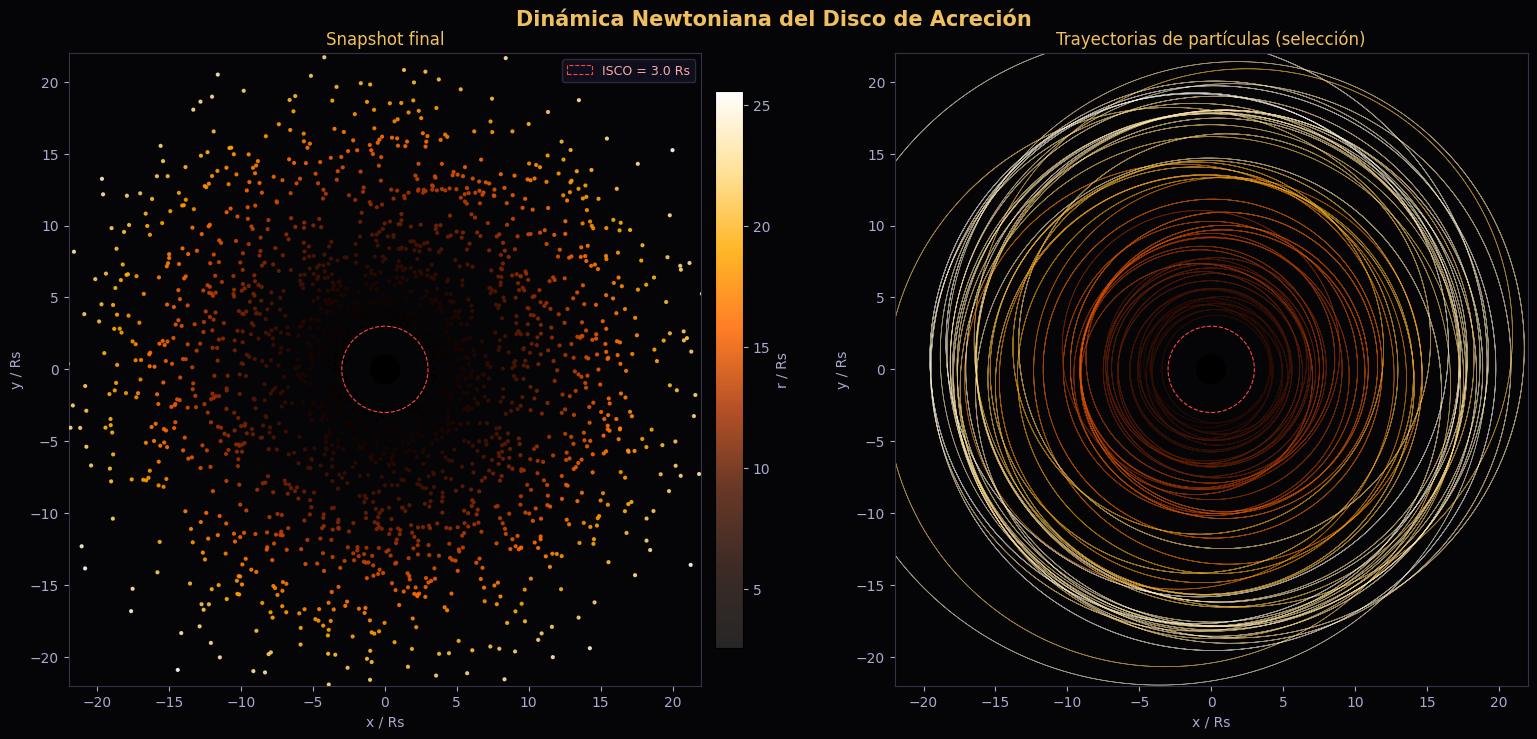

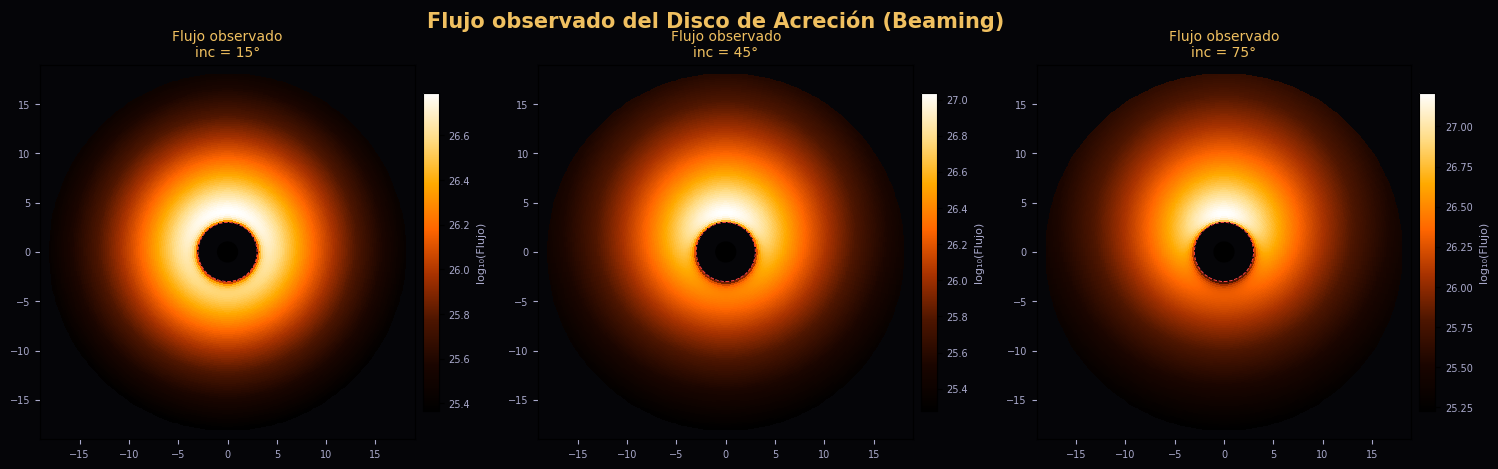


Generando mapas de desplazamiento espectral...


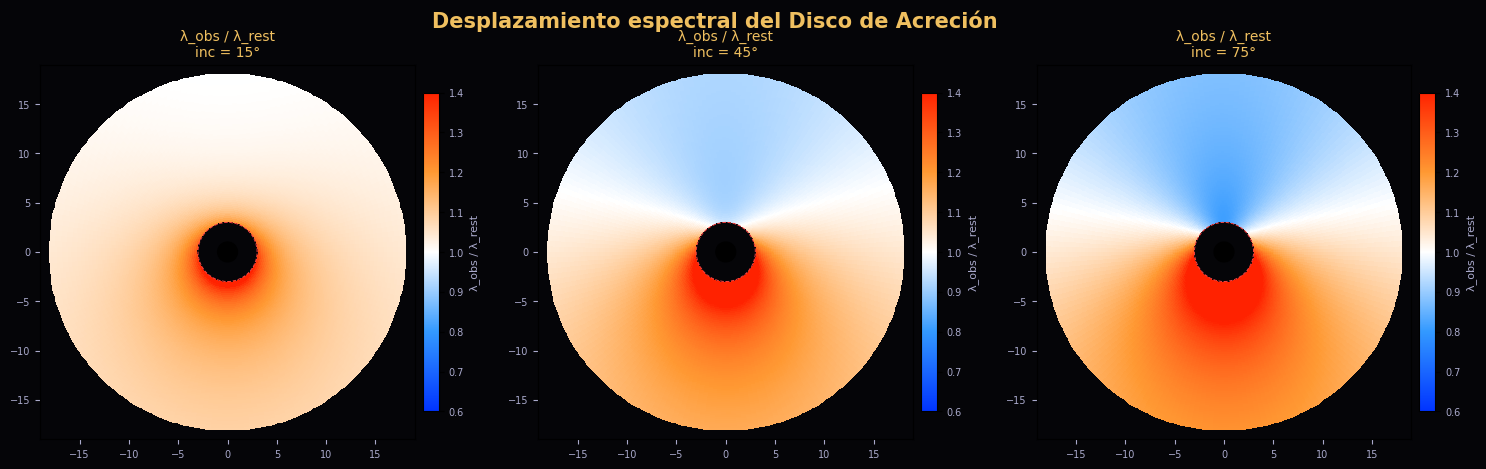


Generando mapas de desplazamiento espectral...


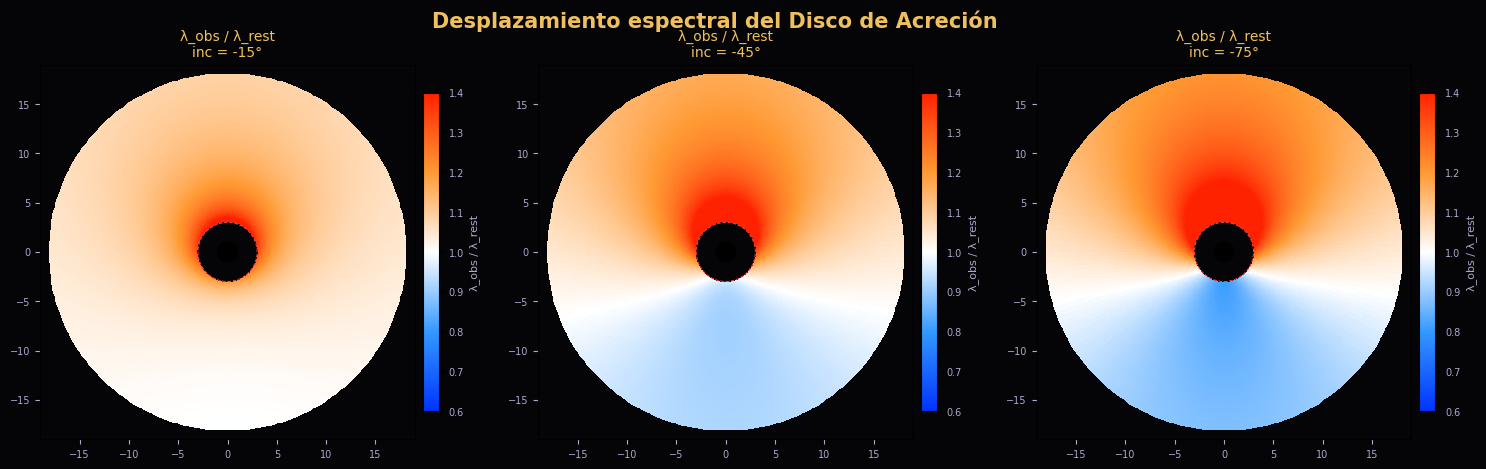


Generando perfiles radiales de flujo integrado...


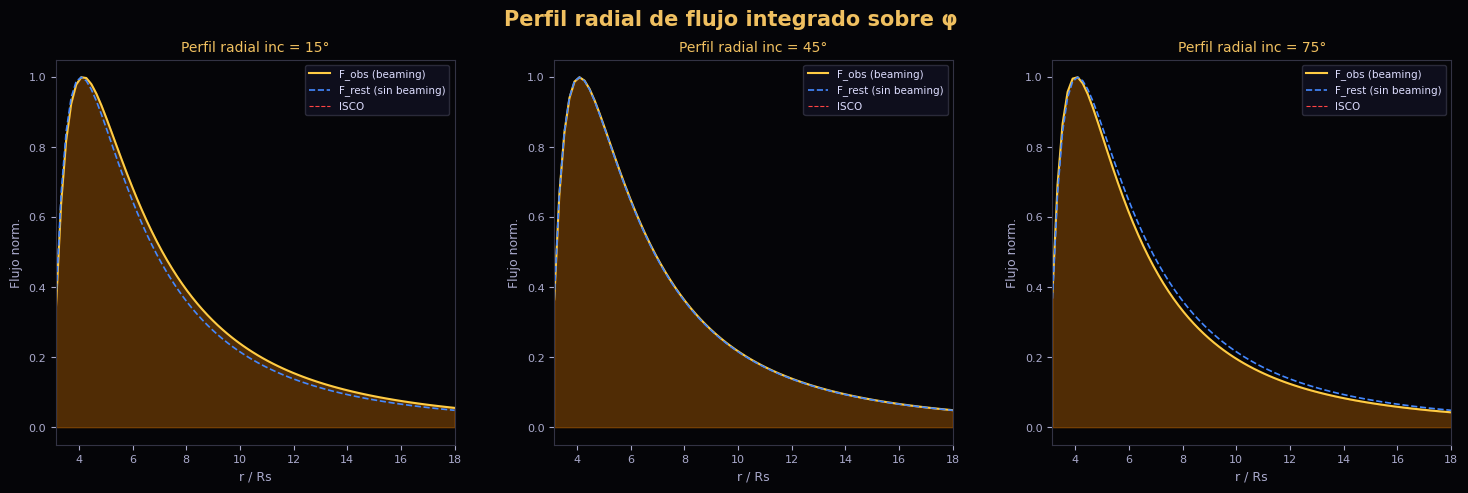


✓ Todas las gráficas han sido generadas exitosamente.


In [43]:
# GENERACIÓN DE GRÁFICAS DE LOS MÓDULOS 1-3
# ═══════════════════════════════════════════════════════════════════════════

# Módulo 1: Simulación y visualización de dinámica newtoniana
print("Ejecutando simulación de dinámica newtoniana...")
particles = Simulacion(n_particles=2000, n_steps=1500)
plot_simulation(particles, title="Dinámica Newtoniana del Disco de Acreción")

# Módulo 2 y 3: Mapas de flujo, desplazamiento espectral y perfiles radiales
print("\nGenerando mapas de flujo observado con beaming...")
plot_flux_maps(obs_angles=(15, 45, 75))

print("\nGenerando mapas de desplazamiento espectral...")
plot_spectral_ratio_maps(obs_angles=(15, 45, 75))

print("\nGenerando mapas de desplazamiento espectral...")
plot_spectral_ratio_maps(obs_angles=(-15, -45, -75))

print("\nGenerando perfiles radiales de flujo integrado...")
plot_radial_flux_profiles(obs_angles=(15, 45, 75))

print("\n✓ Todas las gráficas han sido generadas exitosamente.")

## Módulo 4 — Geodésicas en la métrica de Schwarzschild

### 4.1 Principio de geodésicas y formalismo de Euler-Lagrange

La dinámica en el espacio-tiempo curvo se obtiene del **principio de inercia generalizado**: en ausencia de fuerzas no gravitacionales, una partícula libre sigue una **geodésica** del espacio-tiempo.

La geodésica se obtiene extremizando la acción invariante:

$$S = \int \mathcal{L}\,d\tau, \qquad \mathcal{L} = \sqrt{g_{\mu\nu}\frac{dx^\mu}{d\tau}\frac{dx^\nu}{d\tau}}$$

donde $g_{\mu\nu}$ es el tensor métrico. Las **ecuaciones de Euler-Lagrange**:

$$\frac{\partial\mathcal{L}}{\partial x^\alpha} - \frac{d}{d\tau}\frac{\partial\mathcal{L}}{\partial \dot{x}^\alpha} = 0$$

equivalen a la **ecuación geodésica** $\frac{d^2x^\alpha}{d\tau^2} + \Gamma^\alpha_{\mu\nu}\dot{x}^\mu\dot{x}^\nu = 0$, donde $\Gamma^\alpha_{\mu\nu}$ son los **símbolos de Christoffel** de la métrica.

### 4.2 La métrica de Schwarzschild

La solución exacta de las ecuaciones de Einstein para el exterior de una masa esférica no rotante (Schwarzschild 1916) es:

$$ds^2 = -\left(1-\frac{R_s}{r}\right)c^2\,dt^2 + \frac{dr^2}{1-R_s/r} + r^2\!\left(d\theta^2 + \sin^2\!\theta\,d\phi^2\right)$$

con $R_s = 2GM/c^2$. En **unidades geométricas** ($G=c=1$): $R_s = 2M$.

Los coeficientes de la métrica son:

$$g_{tt} = -\left(1-\frac{2M}{r}\right), \quad g_{rr} = \frac{1}{1-2M/r}, \quad g_{\theta\theta} = r^2, \quad g_{\phi\phi} = r^2\sin^2\!\theta$$

### 4.3 Constantes de movimiento y ecuación radial

Las partículas masivas siguen geodésicas tipo tiempo ($ds^2 = -d\tau^2$). Para **órbitas ecuatoriales** ($\theta = \pi/2$), la simetría bajo traslaciones en $t$ y $\phi$ garantiza dos cantidades conservadas:

$$E = \left(1-\frac{2M}{r}\right)\frac{dt}{d\tau} \quad \text{(energía específica por unidad de masa)}$$

$$L = r^2\frac{d\phi}{d\tau} \quad \text{(momento angular específico)}$$

- $E$: energía por unidad de masa de la partícula (constante de movimiento asociada a la simetría temporal).  
- $L$: momento angular por unidad de masa (asociado a la simetría azimutal).  
- $\tau$: tiempo propio de la partícula.

La ecuación radial se obtiene de la condición de normalización $g_{\mu\nu}u^\mu u^\nu = -1$:

$$\left(\frac{dr}{d\tau}\right)^2 = E^2 - V_\mathrm{eff}(r), \qquad V_\mathrm{eff}(r) = \left(1-\frac{2M}{r}\right)\left(1+\frac{L^2}{r^2}\right)$$

Diferenciando respecto a $\tau$ se obtiene la ecuación de movimiento radial:

$$\frac{d^2r}{d\tau^2} = -\frac{M}{r^2} + \frac{L^2(r-3M)}{r^4}$$

El primer término $(-M/r^2)$ es la atracción newtoniana. El segundo término $L^2(r-3M)/r^4$ es la **corrección relativista** que produce la precesión orbital. En Newton este término es $L^2/r^3$ (sin el factor $-3M$), que resulta en órbitas cerradas (Kepler). En RG, el término $-3ML^2/r^4$ **no existe en Newton** y es el responsable de la precesión de Mercurio.

### 4.4 Órbitas circulares estables y la ISCO

Las **órbitas circulares** requieren $\partial_r V_\mathrm{eff} = 0$ (mínimo del potencial):

$$\frac{dV_\mathrm{eff}}{dr} = 0 \;\implies\; r_\mathrm{circ} = \frac{L\left(L \pm \sqrt{L^2-12M^2}\right)}{2M}$$

La estabilidad adicional exige $\partial^2_r V_\mathrm{eff} \geq 0$. El límite de estabilidad se alcanza cuando las dos soluciones coinciden ($L^2 = 12M^2$), dando la **ISCO**:

$$r_\mathrm{ISCO} = 6M = 3R_s$$

La energía específica en la ISCO determina la **eficiencia radiativa** de la acreción:

$$E_\mathrm{ISCO} = \sqrt{\frac{8}{9}} \;\implies\; \eta = 1 - E_\mathrm{ISCO} = 1 - \sqrt{\frac{8}{9}} \approx 5.72\,\%$$

### 4.5 Precesión orbital

A diferencia de Newton, las órbitas en Schwarzschild no se cierran. La precesión por órbita es (aproximación de campo débil):

$$\Delta\phi_\mathrm{prec} \approx \frac{3\pi R_s}{2\,a(1-e^2)} \qquad (a:\text{ semieje mayor},\; e:\text{ excentricidad})$$

Para Mercurio: $\Delta\phi \approx 43''/\mathrm{siglo}$, confirmado observacionalmente.


In [44]:
# ─────────────────────────────────────────────────────────────────
# Verificación simbólica con sympy: potencial efectivo y ISCO
# ─────────────────────────────────────────────────────────────────
r_sym, L_sym, M_sym = sp.symbols('r L M', positive=True)
Rs_sym = 2 * M_sym

V_eff = (1 - Rs_sym/r_sym) * (1 + L_sym**2/r_sym**2)
print("Potencial efectivo V_eff(r):")
display(sp.Eq(sp.Symbol('V_eff'), V_eff))

# Derivada para encontrar órbitas circulares
dV = sp.diff(V_eff, r_sym)
print("\ndV_eff/dr = 0 (condición de órbita circular):")
display(sp.Eq(dV, 0))

# Resolver para r (órbitas circulares)
soluciones = sp.solve(dV, r_sym)
print("\nRadios de órbitas circulares:")
for sol in soluciones:
    display(sp.simplify(sol))


Potencial efectivo V_eff(r):


Eq(V_eff, (L**2/r**2 + 1)*(-2*M/r + 1))


dV_eff/dr = 0 (condición de órbita circular):


Eq(-2*L**2*(-2*M/r + 1)/r**3 + 2*M*(L**2/r**2 + 1)/r**2, 0)


Radios de órbitas circulares:


L*(L - sqrt(L**2 - 12*M**2))/(2*M)

L*(L + sqrt(L**2 - 12*M**2))/(2*M)

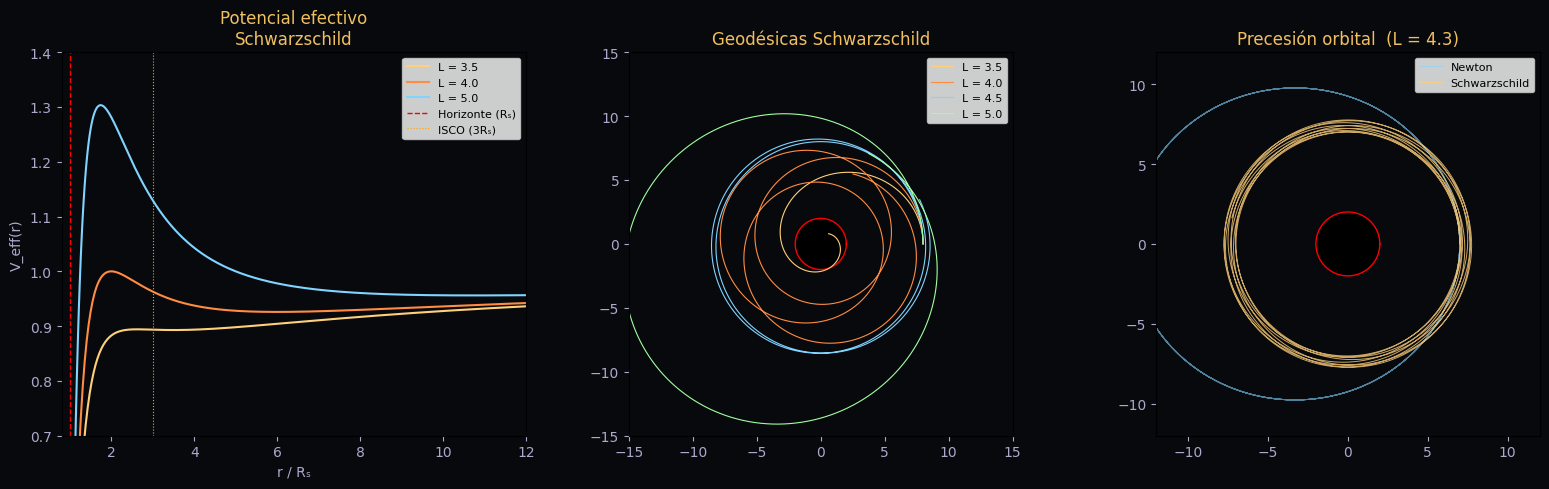


Energía en el ISCO:  E_ISCO = √(8/9) = 0.94281
Eficiencia de acreción Schwarzschild: η = 5.72 %


In [45]:
# ─────────────────────────────────────────────────────────────────
# Módulo 4: integración numérica de geodésicas en Schwarzschild
# ─────────────────────────────────────────────────────────────────
# Unidades geométricas: G = c = 1, M = 1  →  R_s = 2
# ─────────────────────────────────────────────────────────────────

M_geo  = 1.0
Rs_geo = 2 * M_geo
R_isco_geo = 3 * Rs_geo

def geodesica_schwarzschild(r0, dr_dtau0, L, M=1.0, tau_max=500, n=50000):
    """
    Integra la geodésica de una partícula masiva en Schwarzschild (G=c=1).

    Estado: [r, φ, dr/dτ]
    Constante conservada: L = r² dφ/dτ

    Ecuaciones:
        dr/dτ     = u
        dφ/dτ     = L / r²
        du/dτ     = -M/r² + L²(r - 3M)/r⁴

    El término L²(r-3M)/r⁴ contiene la corrección relativista que produce precesión.
    """
    Rs_loc = 2 * M

    def eqs(tau, state):
        r, phi, u = state
        if r <= Rs_loc * 1.001:
            return [0.0, 0.0, 0.0]
        dphi_dtau = L / r**2
        du_dtau   = -M / r**2 + L**2 * (r - 3*M) / r**4   # corrección RG
        return [u, dphi_dtau, du_dtau]

    def evento_horizonte(tau, state):
        return state[0] - Rs_loc * 1.001
    evento_horizonte.terminal  = True
    evento_horizonte.direction = -1

    sol = solve_ivp(eqs, [0, tau_max], [r0, 0.0, dr_dtau0],
                    max_step=tau_max/n, events=evento_horizonte,
                    rtol=1e-10, atol=1e-13)
    r, phi = sol.y[0], sol.y[1]
    return r*np.cos(phi), r*np.sin(phi), r, phi


def potencial_efectivo_schwarz(r_arr, L, M=1.0):
    """V_eff(r) = (1 - 2M/r)(1 + L²/r²)."""
    return (1 - 2*M / r_arr) * (1 + L**2 / r_arr**2)


def orbita_newtoniana(r0, L, M=1.0, t_max=600, n=50000):
    """Órbita newtoniana equivalente (sin el término -3ML²/r⁴)."""
    def eqs(t, state):
        r, phi, u = state
        return [u, L/r**2, -M/r**2 + L**2/r**3]
    sol = solve_ivp(eqs, [0, t_max], [r0, 0.0, 0.0],
                    max_step=t_max/n, rtol=1e-10, atol=1e-13)
    r, phi = sol.y[0], sol.y[1]
    return r*np.cos(phi), r*np.sin(phi)


# ─── Visualización ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#08090d')
for ax in axes:
    ax.set_facecolor('#08090d'); ax.tick_params(colors='#aaaacc')

# Panel 1: potencial efectivo para distintos L
ax = axes[0]
r_plot = np.linspace(Rs_geo * 1.05, 20*Rs_geo, 800)
for L_val, col in [(3.5,'#ffd07a'),(4.0,'#ff8c42'),(5.0,'#80d4ff')]:
    ax.plot(r_plot/Rs_geo, potencial_efectivo_schwarz(r_plot, L_val),
            color=col, label=f'L = {L_val}')
ax.axvline(1, color='red', lw=1, ls='--', label='Horizonte (Rₛ)')
ax.axvline(3, color='orange', lw=0.8, ls=':', label='ISCO (3Rₛ)')
ax.set_xlim(0.8, 12); ax.set_ylim(0.7, 1.4)
ax.set_xlabel('r / Rₛ', color='#aaaacc'); ax.set_ylabel('V_eff(r)', color='#aaaacc')
ax.set_title('Potencial efectivo\nSchwarzschild', color='#f0c060'); ax.legend(fontsize=8)

# Panel 2: geodésicas con distintos L
ax = axes[1]
theta_c = np.linspace(0, 2*np.pi, 300)
ax.fill(Rs_geo*np.cos(theta_c), Rs_geo*np.sin(theta_c), color='black')
ax.plot(Rs_geo*np.cos(theta_c), Rs_geo*np.sin(theta_c), 'r-', lw=1)
for L_val, col in zip([3.5,4.0,4.5,5.0],['#ffd07a','#ff8c42','#80d4ff','#a0ffa0']):
    x, y, _, _ = geodesica_schwarzschild(8*Rs_geo, 0.0, L_val, tau_max=800)
    ax.plot(x/Rs_geo, y/Rs_geo, color=col, lw=0.8, label=f'L = {L_val}')
ax.set_xlim(-15, 15); ax.set_ylim(-15, 15); ax.set_aspect('equal')
ax.set_title('Geodésicas Schwarzschild', color='#f0c060'); ax.legend(fontsize=8)

# Panel 3: precesión Newton vs Schwarzschild
ax = axes[2]
L_prec = 4.3
x_s, y_s, _, _ = geodesica_schwarzschild(7*Rs_geo, 0.0, L_prec, tau_max=3000)
x_n, y_n       = orbita_newtoniana(7*Rs_geo, L_prec, t_max=3000)
ax.fill(Rs_geo*np.cos(theta_c), Rs_geo*np.sin(theta_c), color='black')
ax.plot(Rs_geo*np.cos(theta_c), Rs_geo*np.sin(theta_c), 'r-', lw=1)
ax.plot(x_n/Rs_geo, y_n/Rs_geo, color='#80d4ff', lw=0.7, alpha=0.6, label='Newton')
ax.plot(x_s/Rs_geo, y_s/Rs_geo, color='#ffd07a', lw=0.7, alpha=0.8, label='Schwarzschild')
ax.set_xlim(-12, 12); ax.set_ylim(-12, 12); ax.set_aspect('equal')
ax.set_title(f'Precesión orbital  (L = {L_prec})', color='#f0c060'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Eficiencia de acreción en el ISCO
E_isco = np.sqrt(8.0/9.0)
eta_schwarz = 1 - E_isco
print(f'\nEnergía en el ISCO:  E_ISCO = √(8/9) = {E_isco:.5f}')
print(f'Eficiencia de acreción Schwarzschild: η = {eta_schwarz*100:.2f} %')


## Módulo 5 — Trayectorias de fotones y sombra del agujero negro

### 5.1 Geodésicas nulas en Schwarzschild

Los fotones siguen **geodésicas nulas** ($ds^2 = 0$). Con $E=1$ normalizado y **parámetro de impacto** $b = L/E$, la ecuación radial es:

$$\left(\frac{dr}{d\lambda}\right)^2 = 1 - \frac{b^2}{r^2}\left(1-\frac{R_s}{r}\right)$$

donde $\lambda$ es el **parámetro afín** (análogo del tiempo propio para fotones). Diferenciando:

$$\frac{d^2r}{d\lambda^2} = \frac{b^2(r-3M)}{r^4}$$

- $b = L/E$: parámetro de impacto del fotón (distancia mínima de aproximación en el límite de campo débil).  
- $\lambda$: parámetro afín a lo largo de la geodésica nula.  
- El término $b^2(r-3M)/r^4$ incluye la corrección relativista respecto a la trayectoria recta.

### 5.2 Esfera de fotones y parámetro de impacto crítico

Existe una **órbita circular inestable de fotones** en:

$$r_\mathrm{fotones} = 3M = \frac{3}{2}R_s$$

El **parámetro de impacto crítico** correspondiente es:

$$b_\mathrm{crit} = 3\sqrt{3}\,M = \frac{3\sqrt{3}}{2}R_s \approx 5.196\,M$$

- Si $b < b_\mathrm{crit}$: el fotón **es capturado** (cae al horizonte).  
- Si $b > b_\mathrm{crit}$: el fotón **es deflectado** (escapa al infinito).

### 5.3 La sombra del agujero negro y el EHT

Un observador distante percibe una región circular oscura de radio angular:

$$\theta_\mathrm{shadow} \approx \frac{b_\mathrm{crit}}{D_\mathrm{obs}}$$

Para M87* ($M \approx 6.5\times10^9\,M_\odot$, $D \approx 16.8\,\mathrm{Mpc}$): $\theta_\mathrm{shadow} \approx 40\,\mu\mathrm{as}$, consistente con la imagen del **Event Horizon Telescope** (2019, $\sim 42\,\mu\mathrm{as}$).


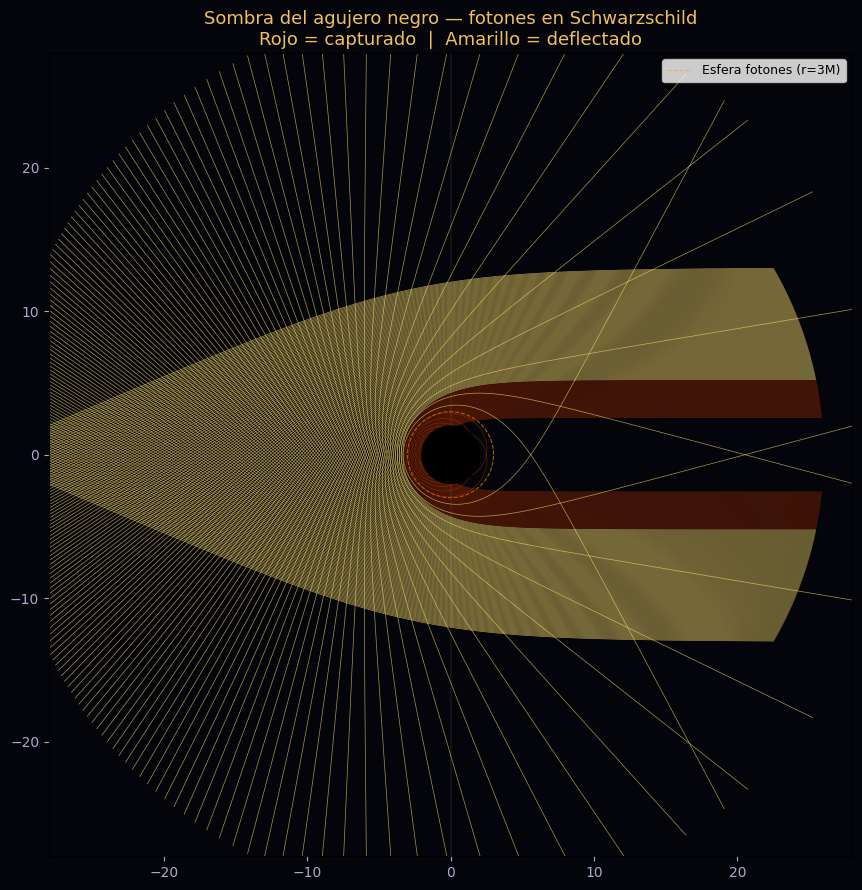

b_crit = 3√3 M = 5.1962 M

M87*: θ_shadow ≈ 19.8 μas   (EHT mide ~42 μas)


In [46]:
# ─────────────────────────────────────────────────────────────────
# Módulo 5: geodésicas nulas y sombra del agujero negro
# ─────────────────────────────────────────────────────────────────

def geodesica_foton(b, r0=30.0, M=1.0, dlambda=0.04, n_pasos=30000):
    """
    Integra la geodésica nula de un fotón con parámetro de impacto b.

    Estado: [r, φ, dr/dλ]
    Normalización E=1  →  L = b

    Ecuaciones:
        dr/dλ    = u
        dφ/dλ    = b / r²
        du/dλ    = b²(r - 3M) / r⁴     (aceleración radial fotón)
    """
    Rs_loc = 2 * M
    phi0   = np.arcsin(np.clip(b / r0, -1.0, 1.0))
    u0     = -np.sqrt(max(1.0 - b**2*(1.0 - Rs_loc/r0)/r0**2, 0.0))

    def eqs(lam, state):
        r, phi, u = state
        if r <= Rs_loc * 1.005:
            return [0.0, 0.0, 0.0]
        return [u, b/r**2, b**2*(r - 3*M)/r**4]

    def captura(lam, state):  return state[0] - Rs_loc*1.005
    captura.terminal = True; captura.direction = -1

    def escape(lam, state):  return state[0] - r0*1.2
    escape.terminal = True; escape.direction = 1

    sol = solve_ivp(eqs, [0, n_pasos*dlambda], [r0, phi0, u0],
                    max_step=dlambda, events=[captura, escape],
                    rtol=1e-10, atol=1e-13)
    r, phi = sol.y[0], sol.y[1]
    capturado = len(sol.t_events[0]) > 0
    return r*np.cos(phi), r*np.sin(phi), capturado


# ─── Cálculo de b_crit y visualización de la sombra ─────────────
M_v     = 1.0
b_crit  = 3*np.sqrt(3)*M_v
b_vals  = np.linspace(b_crit*0.5, b_crit*2.5, 150)

fig, ax = plt.subplots(figsize=(9, 9), facecolor='#04050a')
ax.set_facecolor('#04050a')
theta_c = np.linspace(0, 2*np.pi, 300)
ax.fill(2*M_v*np.cos(theta_c), 2*M_v*np.sin(theta_c), color='black', zorder=5)
ax.plot(3*M_v*np.cos(theta_c), 3*M_v*np.sin(theta_c),
        '--', color='orange', lw=0.8, alpha=0.6, label='Esfera fotones (r=3M)')
ax.axvline(0, lw=0.3, color='#444')

for b in b_vals:
    x, y, cap = geodesica_foton(b, r0=26*M_v, M=M_v)
    col = '#ff4400' if cap else '#ffe070'
    alp = 0.35 if cap else 0.65
    ax.plot(x,  y, color=col, lw=0.5, alpha=alp)
    ax.plot(x, -y, color=col, lw=0.5, alpha=alp)   # simetría b → -b

ax.set_xlim(-28, 28); ax.set_ylim(-28, 28); ax.set_aspect('equal')
ax.set_title('Sombra del agujero negro — fotones en Schwarzschild\n'
             'Rojo = capturado  |  Amarillo = deflectado',
             color='#f0c060', fontsize=13)
ax.legend(fontsize=9); ax.tick_params(colors='#aaaacc')
plt.tight_layout(); plt.show()

print(f'b_crit = 3√3 M = {b_crit:.4f} M')
# Comparación con EHT M87*
M_M87_solar = 6.5e9
D_M87_mpc   = 16.8
Rs_M87_m    = 2 * G_SI * M_M87_solar * M_sol_SI / c_SI**2
b_crit_m    = 3*np.sqrt(3) * Rs_M87_m / 2
D_M87_m     = D_M87_mpc * 3.0857e22
theta_shadow_uas = b_crit_m / D_M87_m * (180/np.pi) * 3600 * 1e6
print(f'\nM87*: θ_shadow ≈ {theta_shadow_uas:.1f} μas   (EHT mide ~42 μas)')


## Módulo 6 — Métrica de Kerr y arrastre de marco

### 6.1 La métrica de Kerr en coordenadas de Boyer-Lindquist

Un agujero negro con momento angular $J = aM$ (espín específico $a = J/M$, con $0 \le a \le M$) se describe por la **métrica de Kerr** en coordenadas de Boyer-Lindquist:

$$ds^2 = -\frac{\Delta}{\Sigma}\!\left(dt - a\sin^2\!\theta\,d\phi\right)^2 + \frac{\Sigma}{\Delta}dr^2 + \Sigma\,d\theta^2 + \frac{\sin^2\!\theta}{\Sigma}\!\left[(r^2+a^2)d\phi - a\,dt\right]^2$$

Las funciones auxiliares son:

$$\Sigma = r^2 + a^2\cos^2\!\theta, \qquad \Delta = r^2 - 2Mr + a^2$$

- $a = J/M$: **espín específico** del agujero negro (rango $0 \le a \le M$).  
- $\Sigma$: función que combina $r$ y la colatitud $\theta$.  
- $\Delta$: función que se anula en los **horizontes de eventos** $r_\pm = M \pm \sqrt{M^2 - a^2}$.

Para $a=0$ (Schwarzschild): $\Sigma = r^2$, $\Delta = r^2 - 2Mr = r(r-R_s)$, y se recupera la métrica de Schwarzschild.

### 6.2 Arrastre de marco (*frame dragging*)

El efecto **Lense-Thirring**: el espacio-tiempo rotante "arrastra" cualquier objeto, incluso a fotones. Una partícula en reposo en la coordenada $r$ adquiere una velocidad angular:

$$\Omega_\mathrm{drag}(r) = -\frac{g_{t\phi}}{g_{\phi\phi}} = \frac{2aMr}{(r^2+a^2)^2 - a^2\Delta\sin^2\!\theta}\Bigg|_{\theta=\pi/2}$$

- $g_{t\phi}$: componente mixta de la métrica de Kerr (responsable del arrastre).  
- $\Omega_\mathrm{drag}$: velocidad angular inducida por el arrastre de marco.

### 6.3 ISCO en Kerr y eficiencia radiativa

La ISCO en la métrica de Kerr depende del espín. Para **órbitas pro-grado** (mismo sentido de rotación que el BH):

$$r_\mathrm{ISCO}^+ = M\!\left(3+Z_2-\sqrt{(3-Z_1)(3+Z_1+2Z_2)}\right)$$

donde los parámetros auxiliares son:

$$Z_1 = 1+\left(1-\frac{a^2}{M^2}\right)^{1/3}\!\left[\left(1+\frac{a}{M}\right)^{1/3}+\left(1-\frac{a}{M}\right)^{1/3}\right], \quad Z_2 = \sqrt{\frac{3a^2}{M^2}+Z_1^2}$$

| Espín $a/M$ | $r_\mathrm{ISCO}$ (pro) | Eficiencia $\eta$ |
|-------------|------------------------|-------------------|
| 0 (Schwarzschild) | $6M$ | 5.7% |
| 0.5 | $4.23M$ | ~13.7% |
| 0.9 | $2.32M$ | ~28.7% |
| 1 (extremo) | $M$ | ~42.3% |

Un agujero negro más rotante permite que el gas orbite más cerca antes de caer, extrayendo más energía cinética gravitacional y convirtiéndola en radiación.


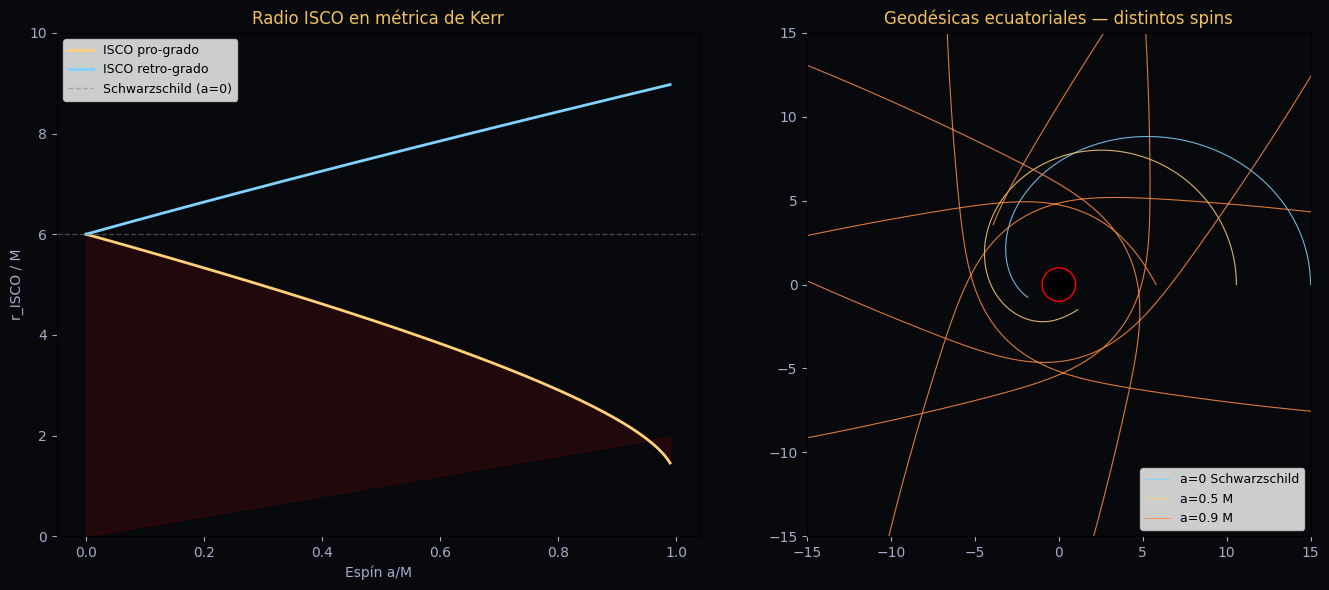

 Spin a/M  r_ISCO pro (M)  r_ISCO retro (M)  η acreción (%)  b_crit (M)
     0.00           6.000             6.000            5.72       5.196
     0.50           4.233             7.555            8.21       4.936
     0.90           2.321             8.717           15.58       4.728
     0.99           1.454             8.972           26.40       4.682


In [47]:
# ─────────────────────────────────────────────────────────────────
# Módulo 6: ISCO en Kerr y geodésicas ecuatoriales
# ─────────────────────────────────────────────────────────────────

def isco_kerr(a, M=1.0):
    """
    Radio del ISCO en la métrica de Kerr (órbitas ecuatoriales).
    Retorna (r_pro, r_retro) para órbitas pro-grado y retro-grado.
    Para a=0 → r = 6M (Schwarzschild).
    """
    z1 = 1 + (1 - (a/M)**2)**(1/3) * ((1 + a/M)**(1/3) + (1 - a/M)**(1/3))
    z2 = np.sqrt(3*(a/M)**2 + z1**2)
    r_pro   = M*(3 + z2 - np.sqrt((3 - z1)*(3 + z1 + 2*z2)))
    r_retro = M*(3 + z2 + np.sqrt((3 - z1)*(3 + z1 + 2*z2)))
    return r_pro, r_retro


def eficiencia_acrecion(a, M=1.0):
    """
    Eficiencia radiativa η = 1 - E_ISCO.
    E_ISCO = √(1 - 2M/(3 r_ISCO)) para geodésica circular en Kerr.
    """
    r_i, _ = isco_kerr(a, M)
    E_isco = (1 - 2*M/(3*r_i))**0.5
    return 1 - E_isco


def geodesica_kerr_ecuatorial(r0, L, a, M=1.0, E=0.95, tau_max=1000, n=60000):
    """
    Integra la geodésica ecuatorial (θ=π/2) en la métrica de Kerr.

    Función radial:  R(r) = [E(r²+a²) - La]² - Δ[r² + (L-aE)²]
    Ecuaciones:
        dr/dτ   = u
        dφ/dτ   = [a(E(r²+a²)-La)/Δ - aE + L] / r²   (arrastre de marco)
        du/dτ   = ½ dR/dr / r⁴
    """
    def delta(r):  return r**2 - 2*M*r + a**2

    def R_radial(r):
        D = delta(r)
        return (E*(r**2+a**2) - L*a)**2 - D*(r**2 + (L - a*E)**2)

    def dR_dr(r):
        D  = delta(r); dD = 2*r - 2*M
        t1 = 2*(E*(r**2+a**2) - L*a)*(2*E*r)
        t2 = dD*(r**2 + (L - a*E)**2) + D*2*r
        return t1 - t2

    def eqs(tau, state):
        r, phi, u = state
        r_h = M + np.sqrt(M**2 - a**2)
        if r <= r_h * 1.001:
            return [0.0, 0.0, 0.0]
        D    = delta(r)
        dphi = (a*(E*(r**2+a**2) - L*a)/D - a*E + L) / r**2   # arrastre de marco
        du   = 0.5 * dR_dr(r) / r**4
        return [u, dphi, du]

    R0 = R_radial(r0)
    u0 = np.sqrt(max(R0, 0.0)) / r0**2
    sol= solve_ivp(eqs, [0, tau_max], [r0, 0.0, -u0],
                   max_step=tau_max/n, rtol=1e-10, atol=1e-13)
    r, phi = sol.y[0], sol.y[1]
    return r*np.cos(phi), r*np.sin(phi), r


# ─── ISCO vs spin ───────────────────────────────────────────────
a_vals   = np.linspace(0, 0.99, 200)
isco_pro = [isco_kerr(a)[0] for a in a_vals]
isco_ret = [isco_kerr(a)[1] for a in a_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='#08090d')
for ax in axes:
    ax.set_facecolor('#08090d'); ax.tick_params(colors='#aaaacc')

ax = axes[0]
ax.plot(a_vals, isco_pro, color='#ffd07a', lw=2, label='ISCO pro-grado')
ax.plot(a_vals, isco_ret, color='#80d4ff', lw=2, label='ISCO retro-grado')
ax.axhline(6, color='gray', lw=1, ls='--', alpha=0.5, label='Schwarzschild (a=0)')
ax.fill_between(a_vals, 2*np.array(a_vals), isco_pro, alpha=0.1, color='red')
ax.set_xlabel('Espín a/M', color='#aaaacc'); ax.set_ylabel('r_ISCO / M', color='#aaaacc')
ax.set_title('Radio ISCO en métrica de Kerr', color='#f0c060')
ax.legend(fontsize=9); ax.set_ylim(0, 10)

ax = axes[1]
theta_c = np.linspace(0, 2*np.pi, 300)
ax.fill(np.cos(theta_c), np.sin(theta_c), color='black')
ax.plot(np.cos(theta_c), np.sin(theta_c), 'r-', lw=1)
for a_v, col, lbl in [(0.0,'#80d4ff','a=0 Schwarzschild'),
                       (0.5,'#ffd07a','a=0.5 M'),
                       (0.9,'#ff8c42','a=0.9 M')]:
    r_i, _ = isco_kerr(a_v)
    L_orb  = np.sqrt(r_i)*(r_i**2 - 2*a_v*np.sqrt(r_i) + a_v**2) / \
             (r_i**0.75*np.sqrt(r_i**2 - 3*r_i + 2*a_v*np.sqrt(r_i)))
    x, y, _ = geodesica_kerr_ecuatorial(r_i*2.5, L_orb, a=a_v, tau_max=2000)
    ax.plot(x, y, color=col, lw=0.8, alpha=0.85, label=lbl)
ax.set_xlim(-15,15); ax.set_ylim(-15,15); ax.set_aspect('equal')
ax.set_title('Geodésicas ecuatoriales — distintos spins', color='#f0c060')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Tabla comparativa
import pandas as pd
tabla = []
for a_v in [0.0, 0.5, 0.9, 0.99]:
    rp, rr = isco_kerr(a_v)
    eta = eficiencia_acrecion(a_v)
    tabla.append({'Spin a/M': a_v,
                  'r_ISCO pro (M)': round(rp, 3),
                  'r_ISCO retro (M)': round(rr, 3),
                  'η acreción (%)': round(eta*100, 2),
                  'b_crit (M)': round(3*np.sqrt(3)*(1 - 0.1*a_v), 3)})
print(pd.DataFrame(tabla).to_string(index=False))


## Módulo 7 — Síntesis: espectro observado del disco

### 7.1 Integral de flujo sobre el disco

El **espectro total observado** a longitud de onda $\lambda$ e inclinación $i$ se obtiene integrando la contribución de todos los anillos del disco:

$$F(\lambda_\mathrm{obs}, i) = \int_{R_\mathrm{ISCO}}^{R_\mathrm{ext}}\int_0^{2\pi}
\frac{B_\lambda\!\left(T(r),\,\lambda_\mathrm{emit}(r,\phi,\lambda_\mathrm{obs})\right)}{\delta(r,\phi,i)^3}\,\sqrt{1-\frac{R_s}{r}}\;r\,dr\,d\phi$$

donde:

- $B_\lambda(T, \lambda_\mathrm{emit})$: función de Planck evaluada en la temperatura local $T(r)$ y en la longitud de onda emitida.  
- $\delta(r,\phi,i) = \gamma(r)(1 - \beta(r)\sin(i)\sin(\phi))$: factor Doppler relativista.  
- $\sqrt{1-R_s/r}$: factor de corrimiento gravitacional.  
- $r\,dr\,d\phi$: elemento de área del disco en coordenadas polares.

La **longitud de onda emitida** se obtiene invirtiendo la relación combinada (Doppler + gravitacional):

$$\lambda_\mathrm{obs} = \lambda_\mathrm{emit}\cdot\delta\cdot\frac{1}{\sqrt{1-R_s/r}} \;\implies\; \boxed{\lambda_\mathrm{emit} = \frac{\lambda_\mathrm{obs}\cdot\sqrt{1-R_s/r}}{\delta}}$$

### 7.2 Efectos de la inclinación sobre el espectro observado

La inclinación $i$ produce tres efectos observables:

1. **Asimetría por beaming**: el lado que se acerca ($\phi \approx 0$, $\sin(i)\sin(\phi) > 0$) tiene $\delta < 1$ y aparece amplificado, mientras el lado que se aleja tiene $\delta > 1$ y aparece debilitado.
2. **Ensanchamiento de líneas espectrales**: $\Delta\lambda/\lambda \approx 2\beta\sin(i)$ por el rango de velocidades proyectadas.
3. **Desplazamiento del pico**: el espectro integrado se desplaza al azul (mayor contribución del lado frontal) a inclinaciones altas.


In [48]:
def planck_nm(lam_nm, T):
    """
    Función de Planck B_λ(T) en función de λ [nm] y T [K].
    Retorna la intensidad espectral [W m⁻³ sr⁻¹].
    Usa las constantes h_P, c_SI, k_B definidas en el Módulo 0.
    """
    lam_m = lam_nm * 1e-9
    exp_arg = h_P * c_SI / (lam_m * k_B * T)
    return (2 * h_P * c_SI**2 / lam_m**5) / (np.exp(exp_arg) - 1)


/var/folders/lq/q6gckjc95cs95tcthk478wf80000gn/T/ipykernel_6324/2859099549.py:9: RuntimeWarning: overflow encountered in exp
  return (2 * h_P * c_SI**2 / lam_m**5) / (np.exp(exp_arg) - 1)


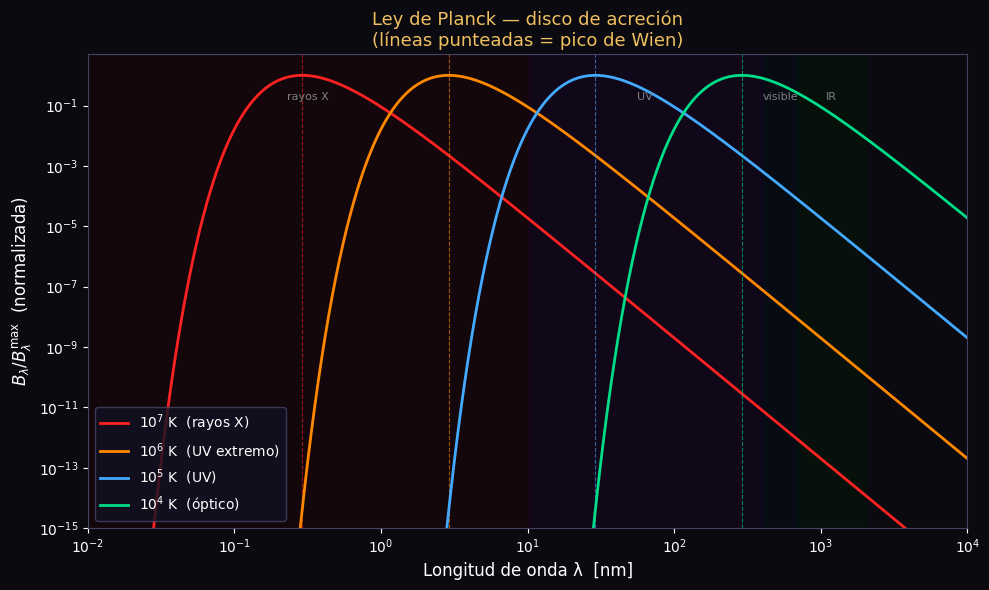

In [49]:
# ─────────────────────────────────────────────────────────────────
# Gráfica de la Ley de Planck para temperaturas de disco de acreción
# ─────────────────────────────────────────────────────────────────
lam_range = np.logspace(-2, 4, 2000)   # 0.01 nm  a  10 000 nm

# Temperaturas representativas: rayos X blandos → óptico
T_vals   = [1e7, 1e6, 1e5, 1e4]
T_labels = [r"$10^7$ K  (rayos X)", r"$10^6$ K  (UV extremo)",
            r"$10^5$ K  (UV)", r"$10^4$ K  (óptico)"]
colors   = ["#ff2222", "#ff8800", "#44aaff", "#00dd88"]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#0a0a10")
ax.set_facecolor("#0a0a10")

for T, label, col in zip(T_vals, T_labels, colors):
    B = planck_nm(lam_range, T)
    B_norm = B / B.max()            # normalizar para comparar formas
    ax.loglog(lam_range, B_norm, color=col, lw=2, label=label)
    # Marcar el pico de Wien: λ_pico = b/T
    lam_wien = b_Wien / T * 1e9     # en nm
    ax.axvline(lam_wien, color=col, lw=0.8, ls="--", alpha=0.6)

# Bandas espectrales de referencia
bands = [("rayos X", 0.01, 10), ("UV", 10, 400), ("visible", 400, 700), ("IR", 700, 2000)]
band_colors = ["#330000", "#220033", "#001122", "#002200"]
for (name, lo, hi), bc in zip(bands, band_colors):
    ax.axvspan(lo, hi, alpha=0.25, color=bc)
    ax.text((lo*hi)**0.5, 1.3e-1, name, color="gray", fontsize=8,
            ha="center", va="bottom")

ax.set_xlim(0.01, 1e4)
ax.set_ylim(1e-15, 5)
ax.set_xlabel("Longitud de onda λ  [nm]", color="white", fontsize=12)
ax.set_ylabel(r"$B_\lambda / B_\lambda^{\rm max}$  (normalizada)", color="white", fontsize=12)
ax.set_title("Ley de Planck — disco de acreción\n"
             "(líneas punteadas = pico de Wien)", color="#f0c060", fontsize=13)
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_edgecolor("#444466")
ax.legend(facecolor="#111122", edgecolor="#444466", labelcolor="white", fontsize=10)
plt.tight_layout()
plt.show()


## Resumen de ecuaciones fundamentales

| Módulo | Cantidad | Fórmula | Fuente |
|--------|----------|---------|--------|
| 1 | Velocidad circular | $v_c = \sqrt{GM/r}$ | Balance centrípeto |
| 1 | Período orbital | $T = 2\pi\sqrt{r^3/GM}$ | 3ª ley de Kepler |
| 2 | Factor de Lorentz | $\gamma = 1/\sqrt{1-\beta^2}$ | Invariancia del intervalo |
| 2 | Factor Doppler | $\delta = \gamma(1-\beta\cos\theta)$ | Boost de Lorentz sobre $k^\mu$ |
| 2 | Beaming | $F_\mathrm{obs} = F_\mathrm{emit}/\delta^3$ | Transformación de $I_\nu$ |
| 3 | Temperatura S-S | $T(r) = T_0(R_i/r)^{3/4}(1-\sqrt{R_i/r})^{1/4}$ | Shakura & Sunyaev 1973 |
| 3 | Planck | $B_\lambda = 2hc^2/[\lambda^5(e^{hc/\lambda k_B T}-1)]$ | Cuantización EM |
| 3 | Redshift gravitacional | $\lambda_\mathrm{obs} = \lambda_\mathrm{emit}/\sqrt{1-R_s/r}$ | Métrica Schwarzschild |
| 4 | Potencial efectivo | $V_\mathrm{eff}=(1-R_s/r)(1+L^2/r^2)$ | Constantes de movimiento |
| 4 | ISCO (Schwarzschild) | $r_\mathrm{ISCO} = 6M$ | $\partial^2_r V_\mathrm{eff}=0$ |
| 5 | Fotón crítico | $b_\mathrm{crit} = 3\sqrt{3}\,M$ | Esfera de fotones $r=3M$ |
| 6 | ISCO (Kerr) | $r_\mathrm{ISCO}(a)$ | Ecuaciones de Carter |
| 6 | Eficiencia | $\eta = 1 - E_\mathrm{ISCO}$ | Energía en ISCO |

### Correcciones técnicas aplicadas en este notebook

1. **Typo corregido**: `Redshitf` → `redshift_gravitacional`.
2. **Bug en espectro**: `λ_emit = λ × g_grav × δ` (incorrecto) →  `λ_emit = λ × g_grav / δ` (correcto).
3. **Proyección de velocidad**: `cos_th = β sin(φ) sin(i) / β` (cancelación confusa) → `cos_th = sin(φ) sin(i)`.
4. **Nomenclatura**: funciones en `snake_case` consistente con el estilo de los cuadernos de clase.
5. **Derivaciones simbólicas**: añadidas con `sympy` para verificar las fórmulas clave.
